In [2]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/commonTools/")
from trainingTools import NFTrainer, loadData, loadMeans
import helper_functions as hf
from functools import partial
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import json
import torch
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
import h5py
#torch.set_default_tensor_type('torch.cuda.FloatTensor') if torch.cuda.is_available() else print ('cpu')

In [3]:
variables = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
varnames = [r"Jet 1 $\rho$",r"Jet 1 $\tau_{21}$",r"Jet 1 $\tau_{32}$",r"Jet 1 $\tau_{43}$",r"Jet 1 $\log\tau_S$",r"Jet 1 $P_b$",r"Jet 1 $n_{PF}$",
            r"Jet 2 $\rho$",r"Jet 2 $\tau_{21}$",r"Jet 2 $\tau_{32}$",r"Jet 2 $\tau_{43}$",r"Jet 2 $\log\tau_S$",r"Jet 1 $P_b$",r"Jet 2 $n_{PF}$"]
bkg = hf.loadData("BKG",variables,nMax=1000000,mode="train",dEta_cut=-1,sideband=False)
bkg_mflat = hf.loadData("BKG_mjjFlat",variables,nMax=-1,mode="train",dEta_cut=-1,sideband=False)
sig = hf.loadData("XYY3000_Y170_Yp170",variables,nMax=1000000,mode="train",dEta_cut=-1,sideband=False)

100%|██████████| 1/1 [00:00<00:00,  3.15it/s]


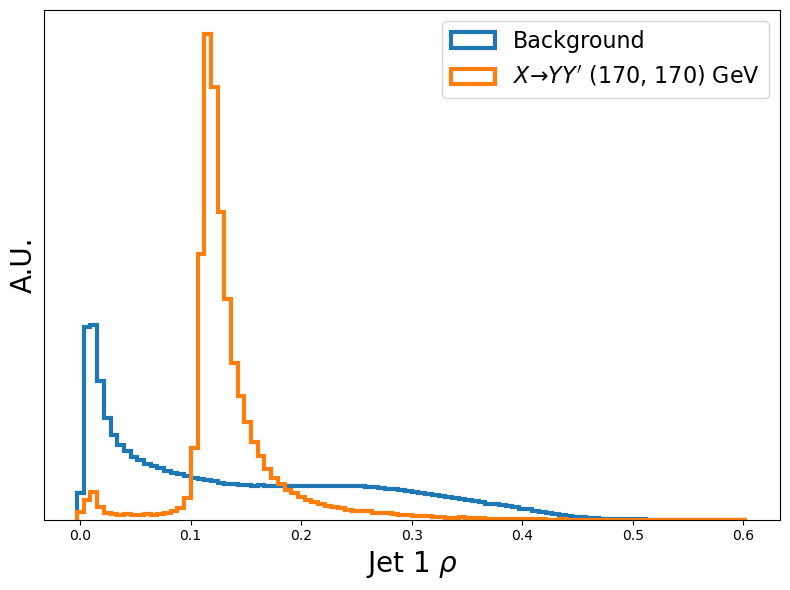

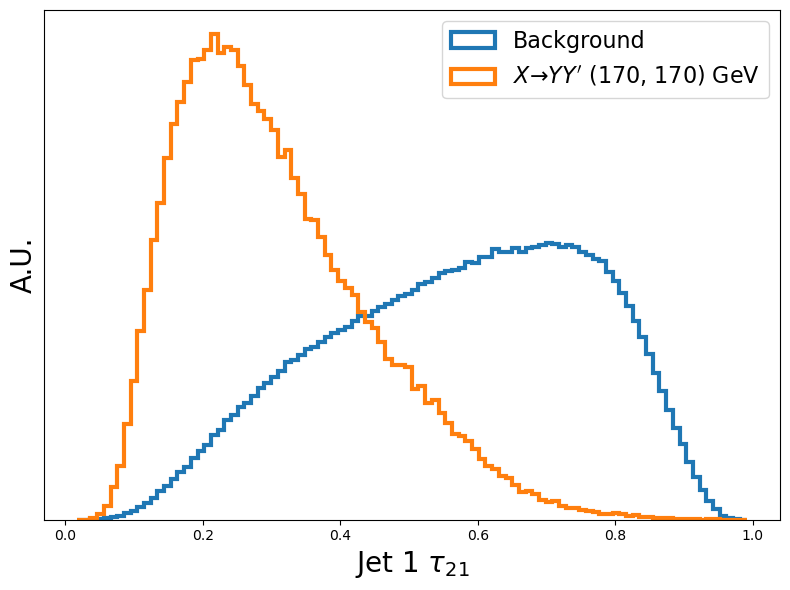

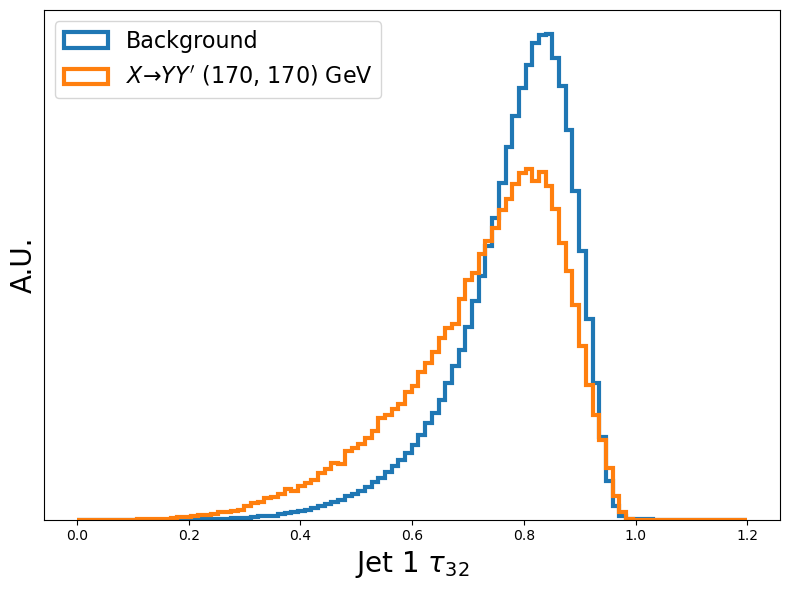

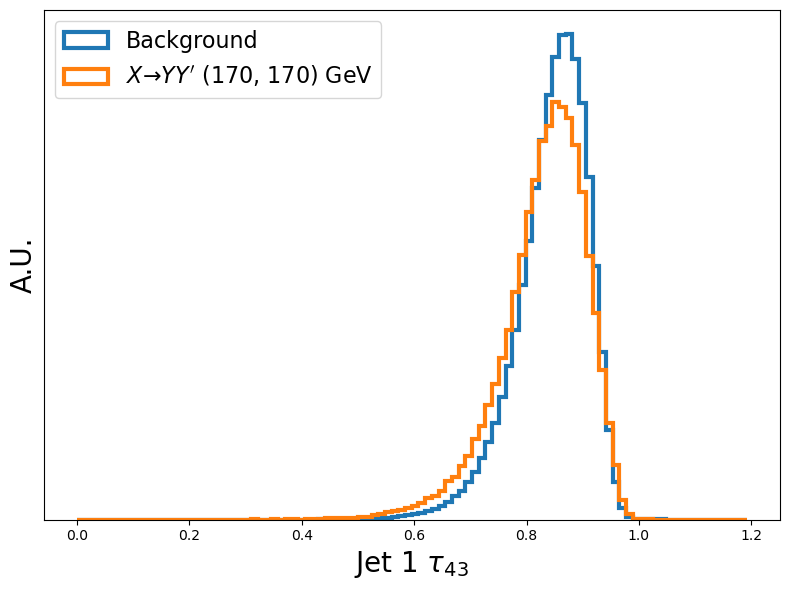

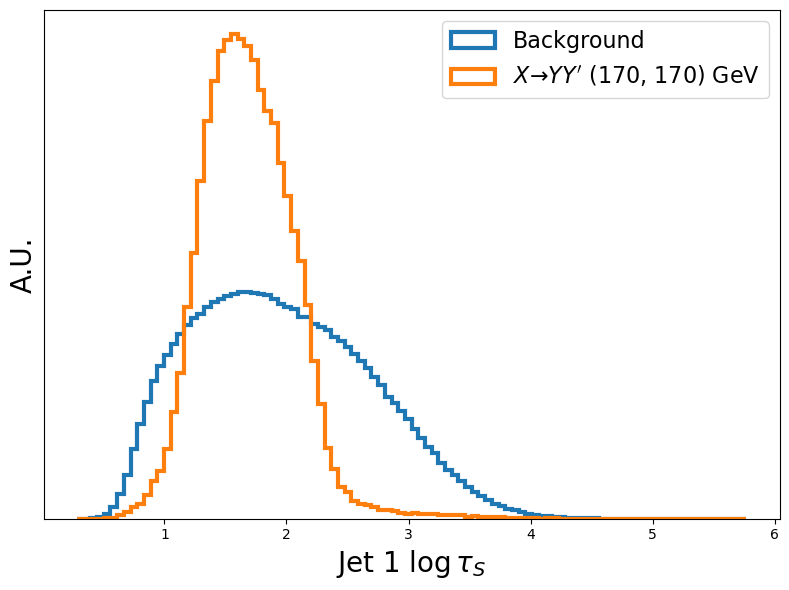

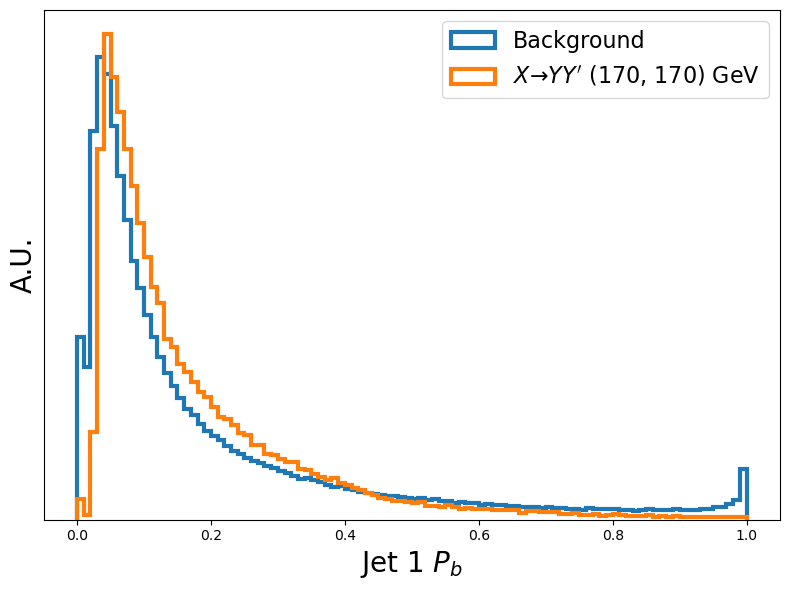

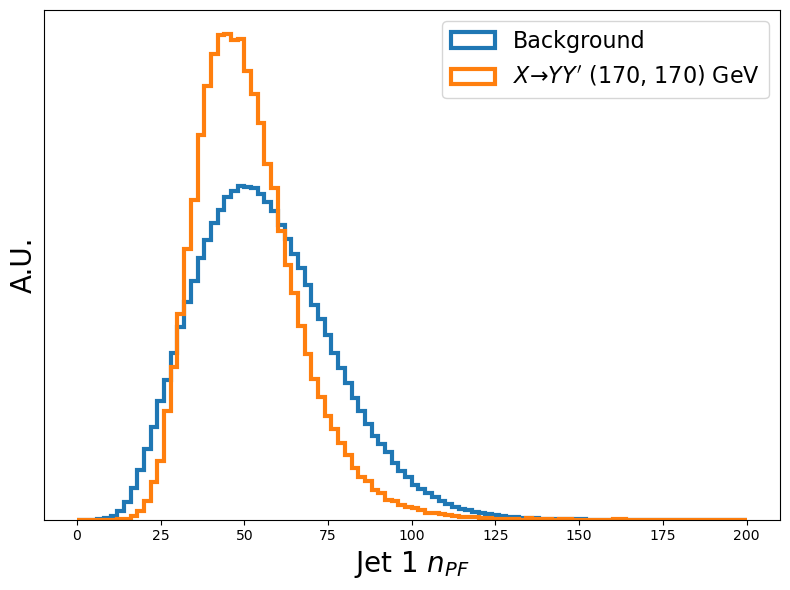

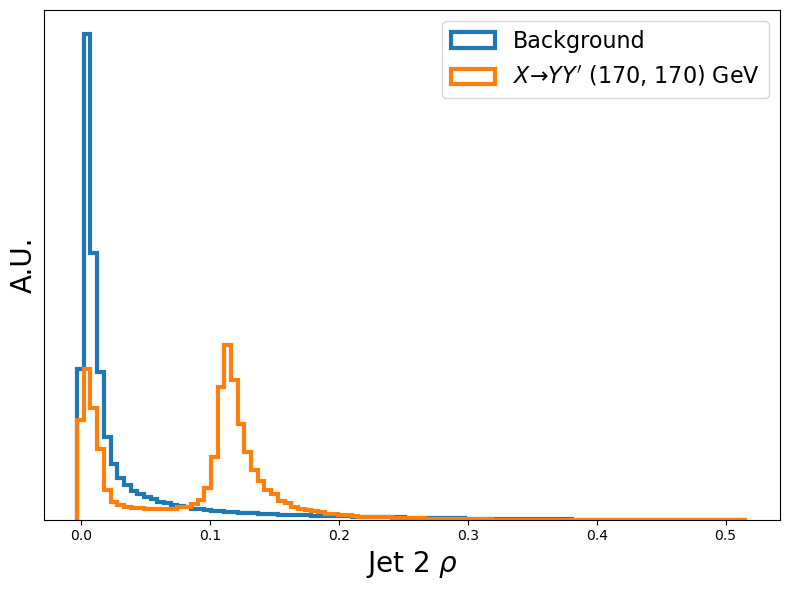

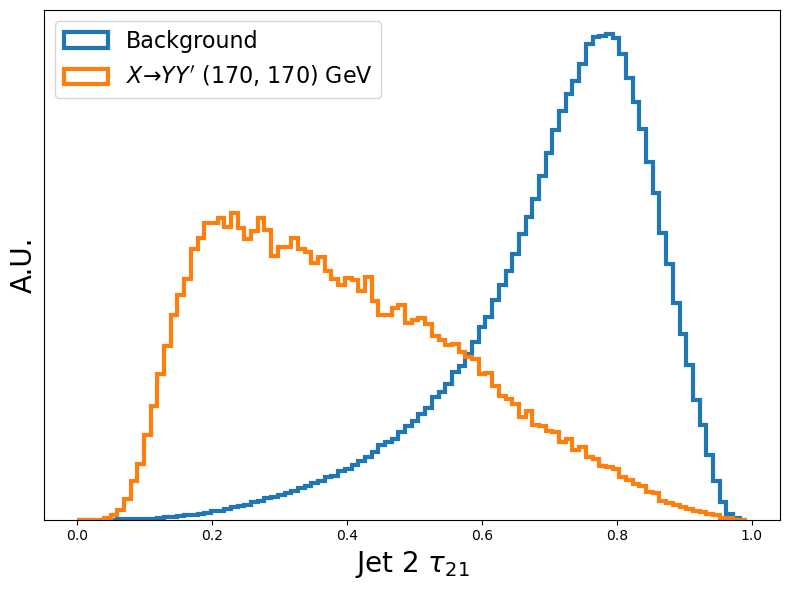

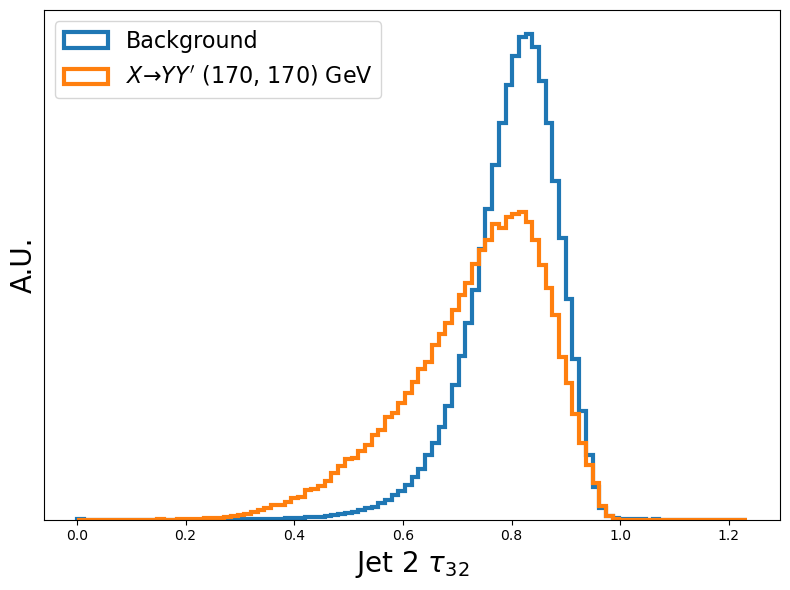

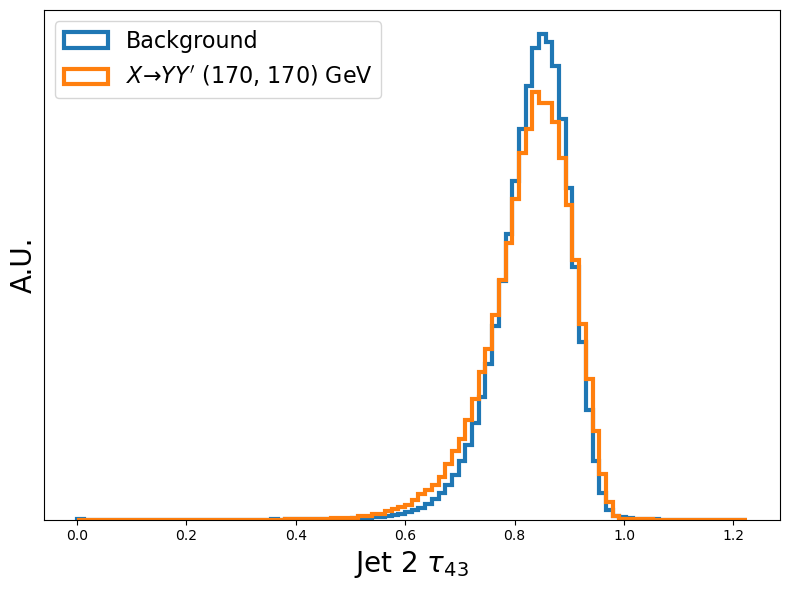

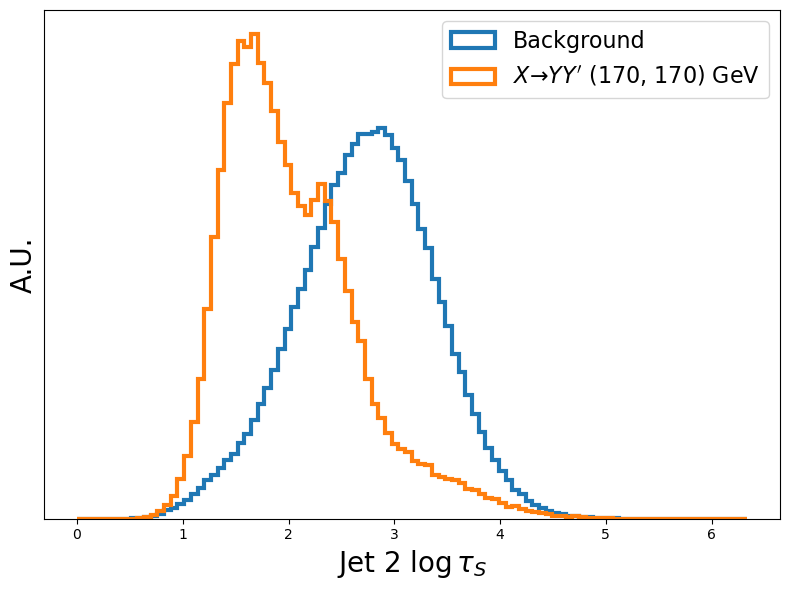

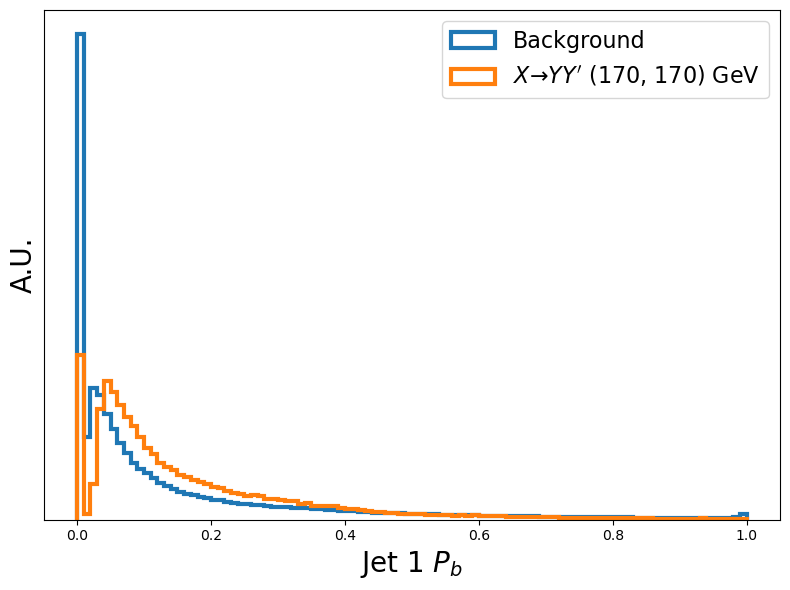

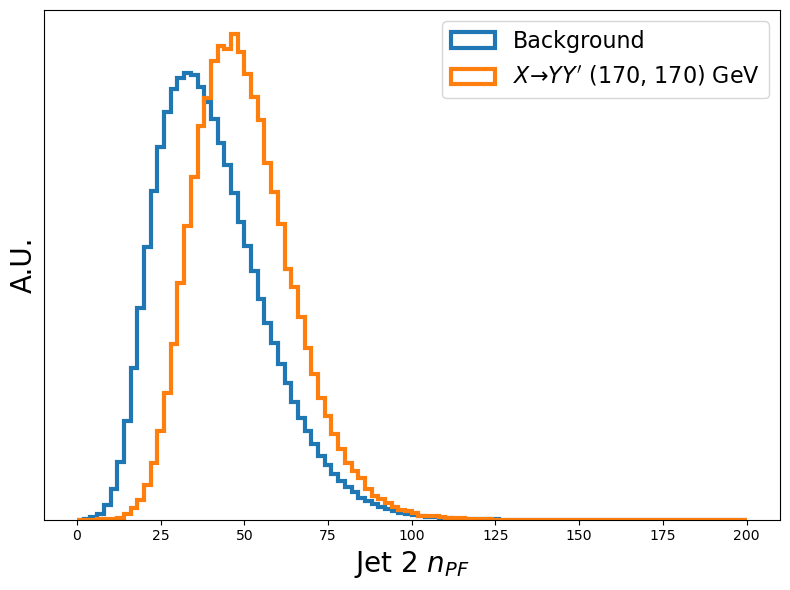

In [6]:
for i,v in enumerate(variables):
    plt.figure(figsize=(8,6))
    bins = np.arange(0,202,2) if "npf" in v else 100
    hb,bins,_ = plt.hist(bkg[:,i],bins=bins,histtype='step',density=True,lw=3,label="Background")
    hs,bins,_ = plt.hist(sig[:,i],bins=bins,histtype='step',density=True,lw=3,label=r"$X \to YY^\prime$ (170, 170) GeV")
    loc = 'best'
    if v == 'jet2_tau21' or 'tau32' in v or 'tau43' in v:
        loc = 'upper left'
    plt.legend(loc=loc,fontsize=16)
    plt.xlabel(varnames[i],fontsize=20)
    plt.ylabel("A.U.",fontsize=20)
    plt.yticks([])
    plt.tight_layout()
    plt.savefig(f"plots/misc/nf_input_{v}.pdf")

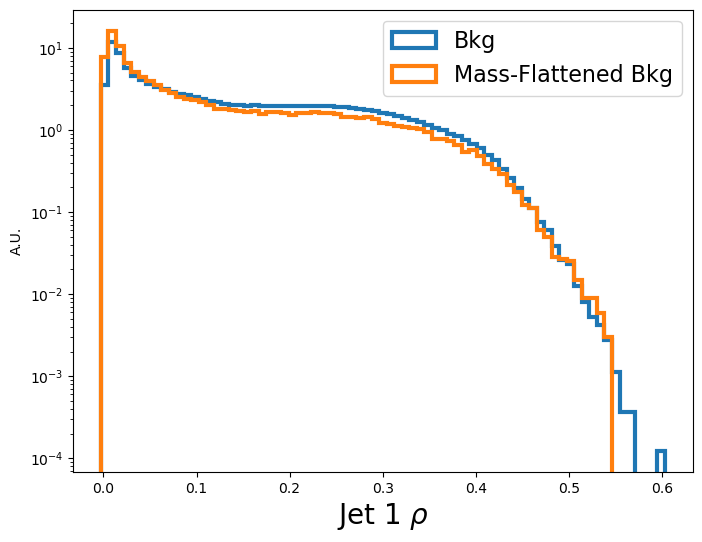

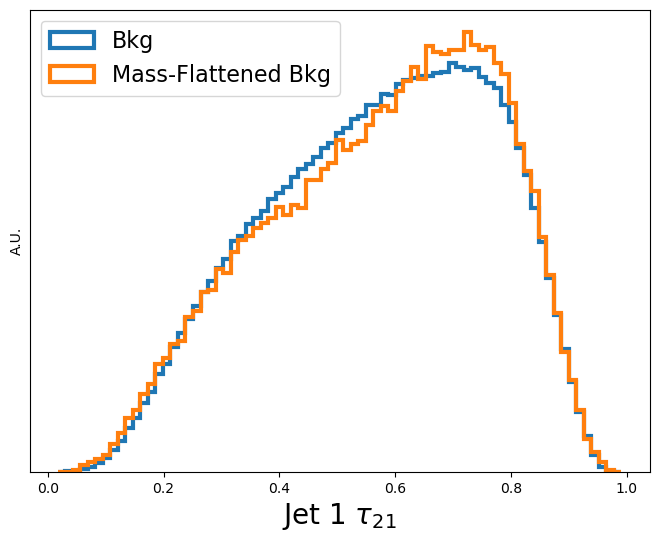

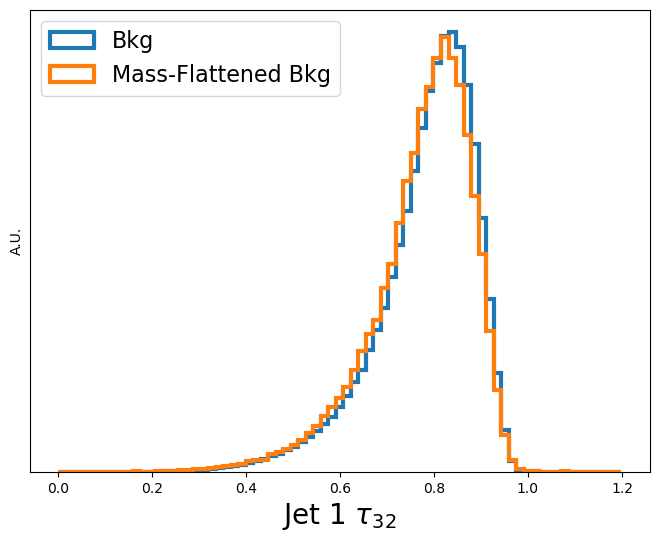

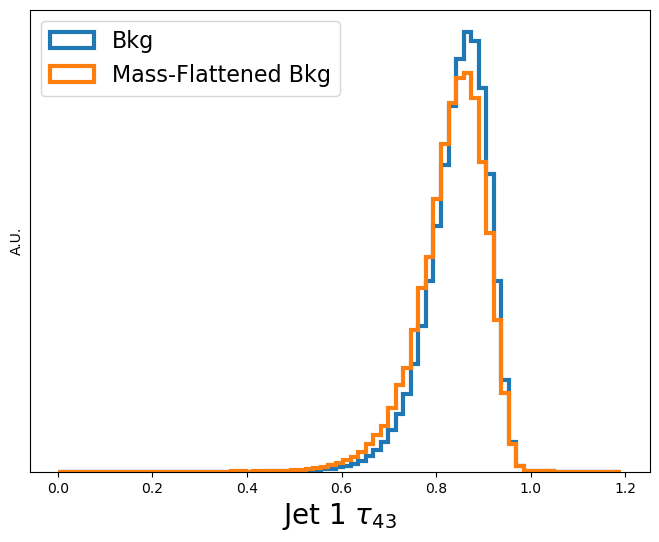

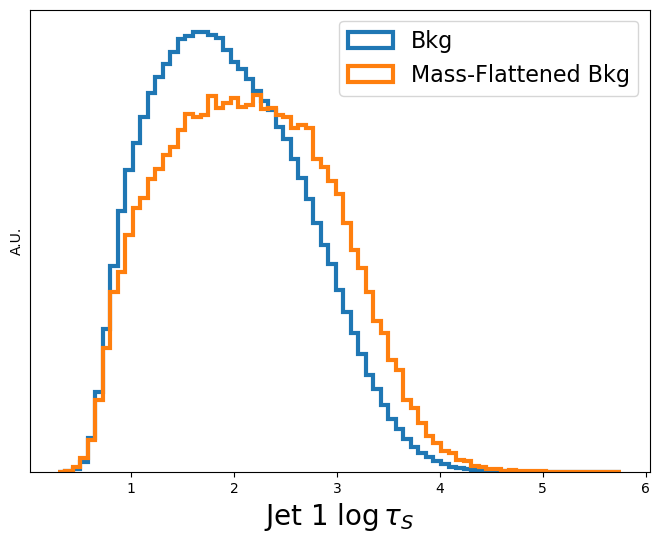

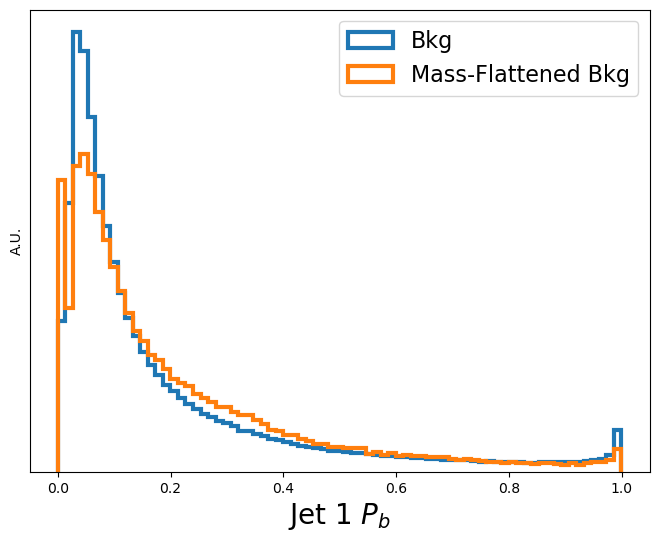

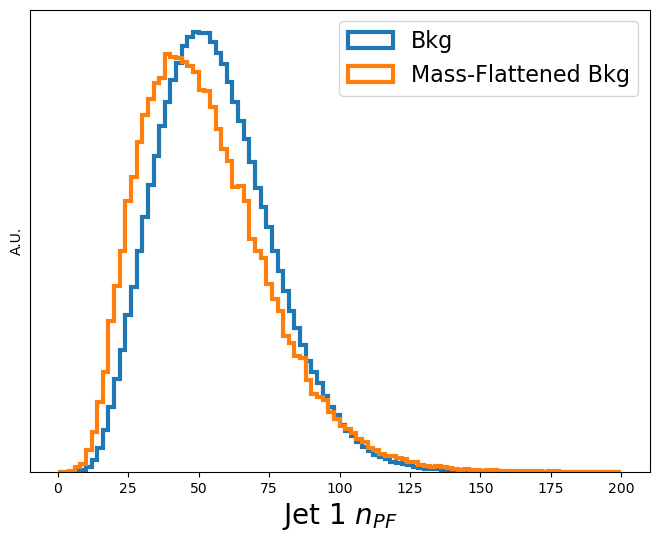

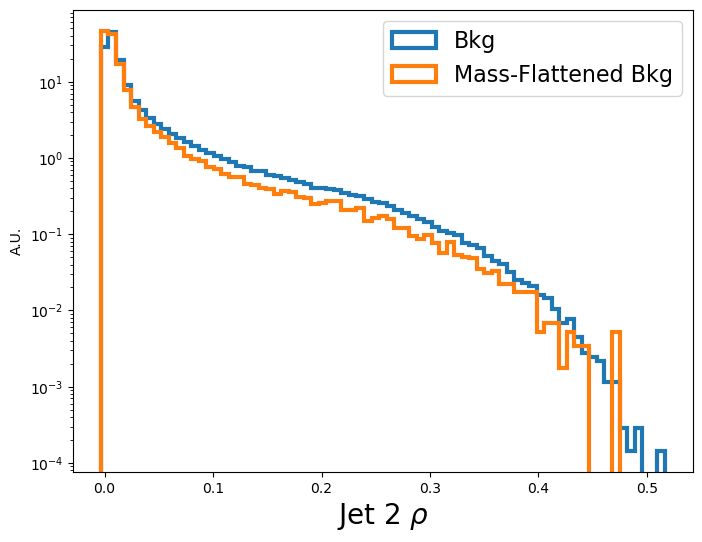

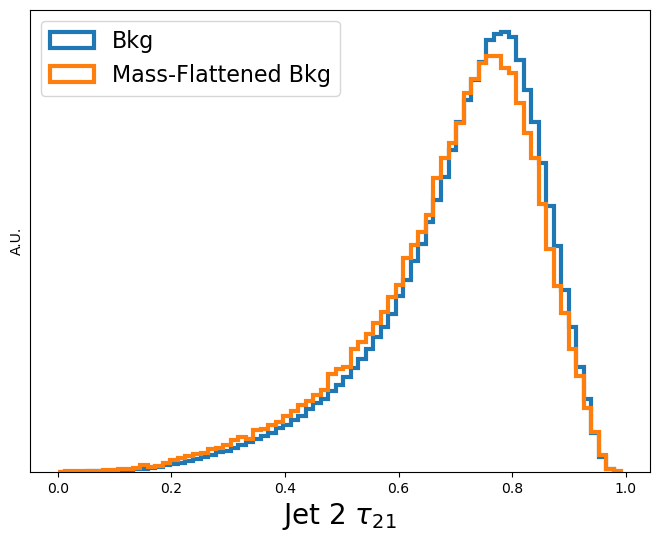

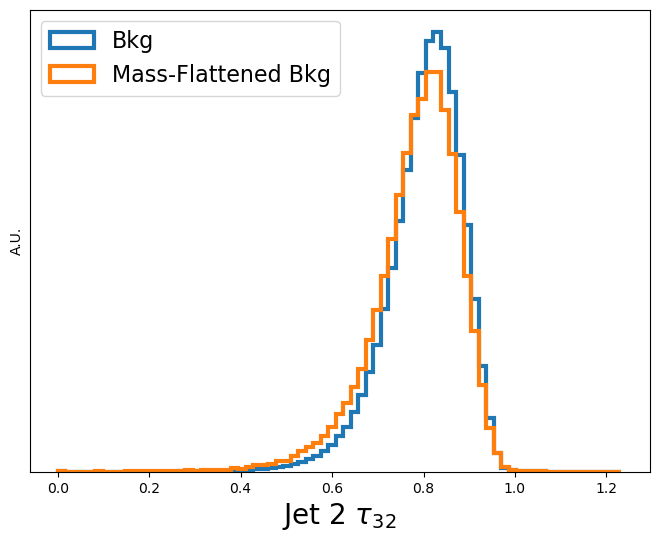

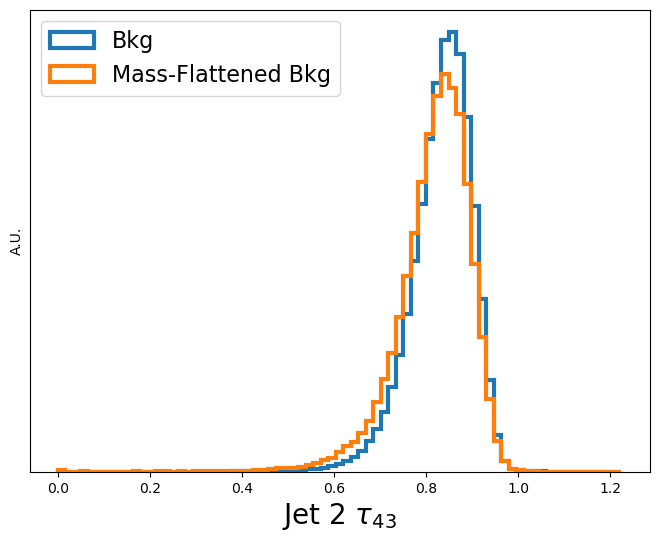

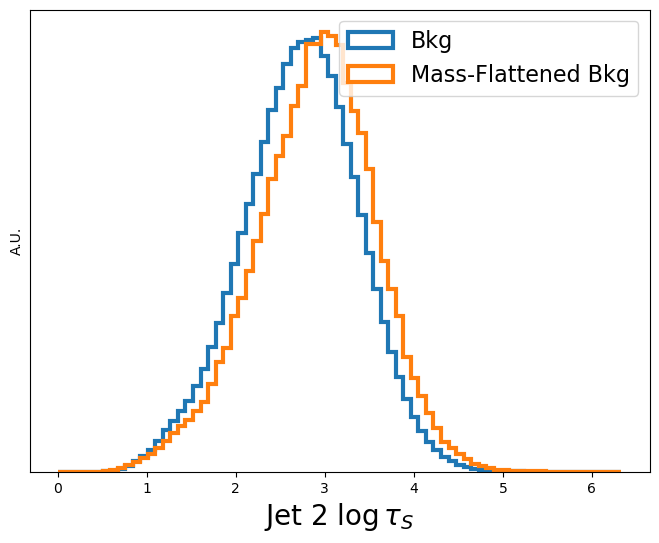

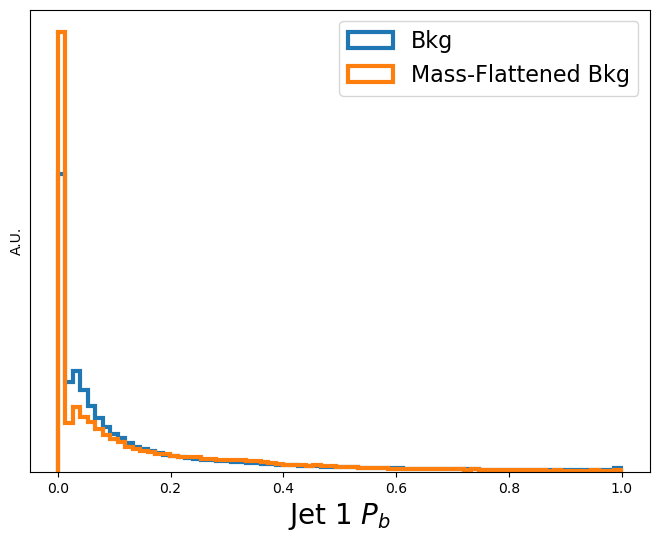

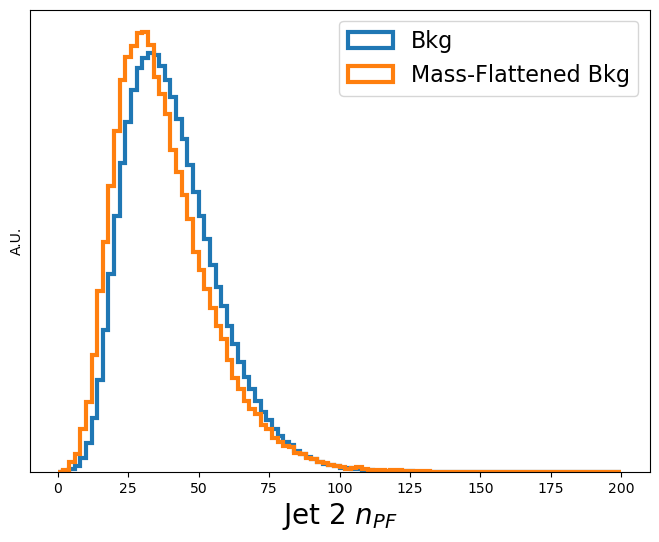

In [9]:
for i,v in enumerate(variables):
    plt.figure(figsize=(8,6))
    bins = np.arange(0,202,2) if "npf" in variables[i] else 75
    hb,bins,_ = plt.hist(bkg[:,i],bins=bins,histtype='step',density=True,lw=3,label="Bkg")
    hs,bins,_ = plt.hist(bkg_mflat[:,i],bins=bins,histtype='step',density=True,lw=3,label=r"Mass-Flattened Bkg")
    loc = 'best'
    if 'tau21' in v or 'tau32' in v or 'tau43' in v:
        loc = 'upper left'
    plt.legend(loc=loc,fontsize=16)
    plt.xlabel(varnames[i],fontsize=20)
    plt.ylabel("A.U.")
    plt.yticks([])
    if 'rho' in v:
        plt.yscale('log')
    plt.savefig(f"plots/misc/bkg_mjjFlatComparison_{v}.pdf")

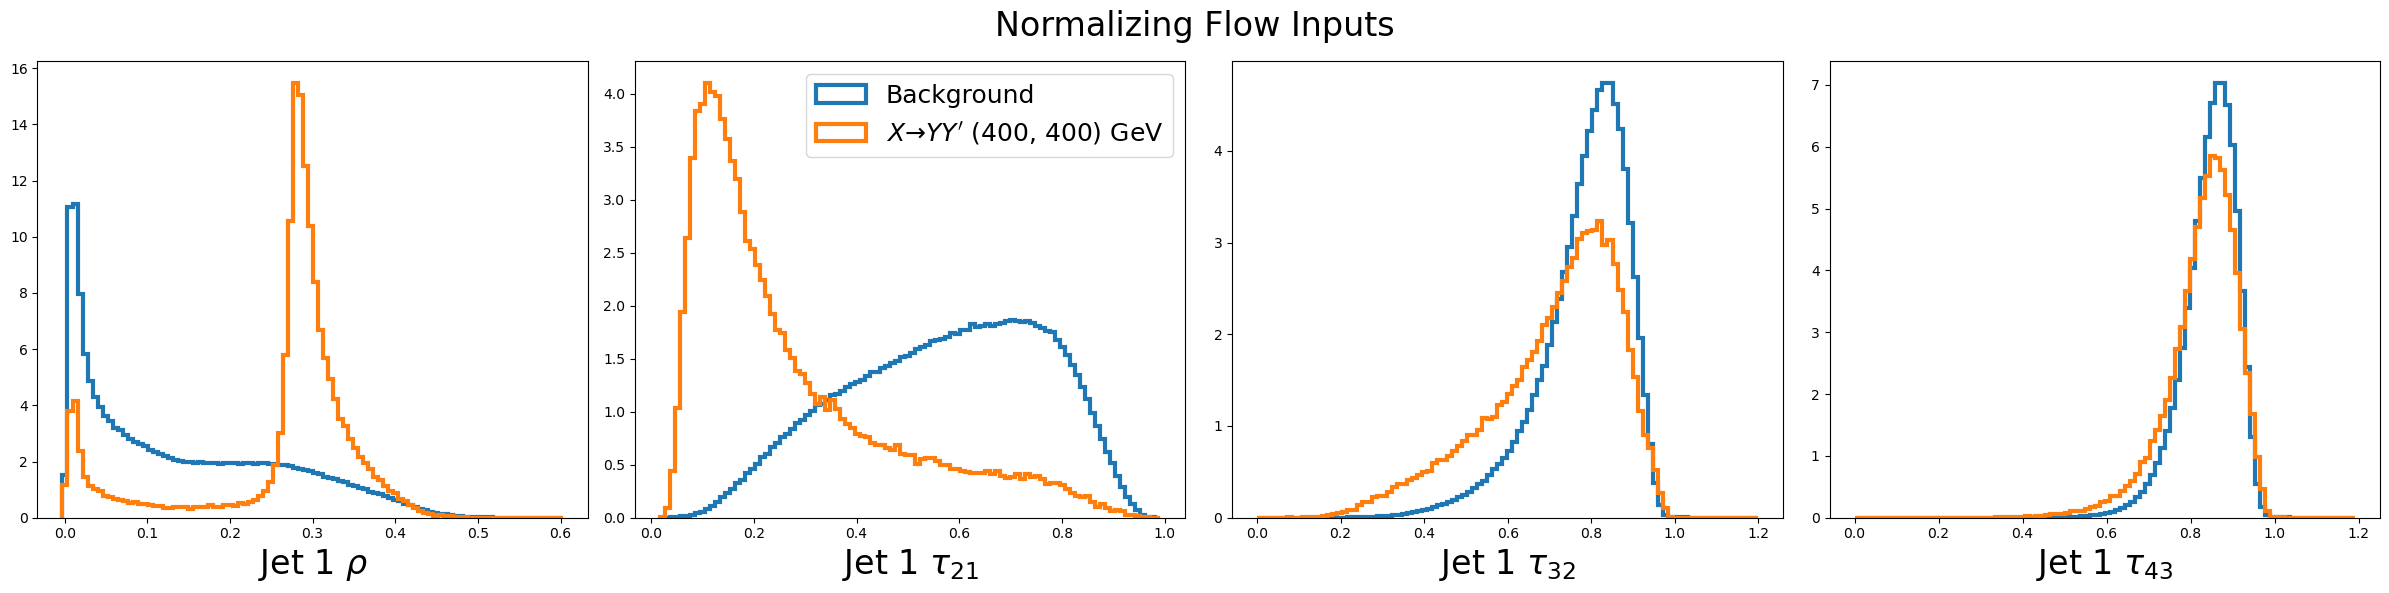

In [8]:
fig,axes = plt.subplots(1,4,figsize=(24,6))
for i in range(4):
    plt.sca(axes.flatten()[i])
    bins = np.arange(0,202,2) if "npf" in variables[i] else 100
    hb,bins,_ = plt.hist(bkg[:,i],bins=bins,histtype='step',density=True,lw=3,label="Background")
    hs,bins,_ = plt.hist(sig[:,i],bins=bins,histtype='step',density=True,lw=3,label=r"$X \to YY^\prime$ (400, 400) GeV")
    if i%7==1:
        plt.legend(loc='best',fontsize=18)
    plt.xlabel(varnames[i],fontsize=24)
plt.suptitle("Normalizing Flow Inputs",fontsize=24)
plt.tight_layout()
plt.savefig("plots/misc/nf_inputs_j1_1to4.pdf")

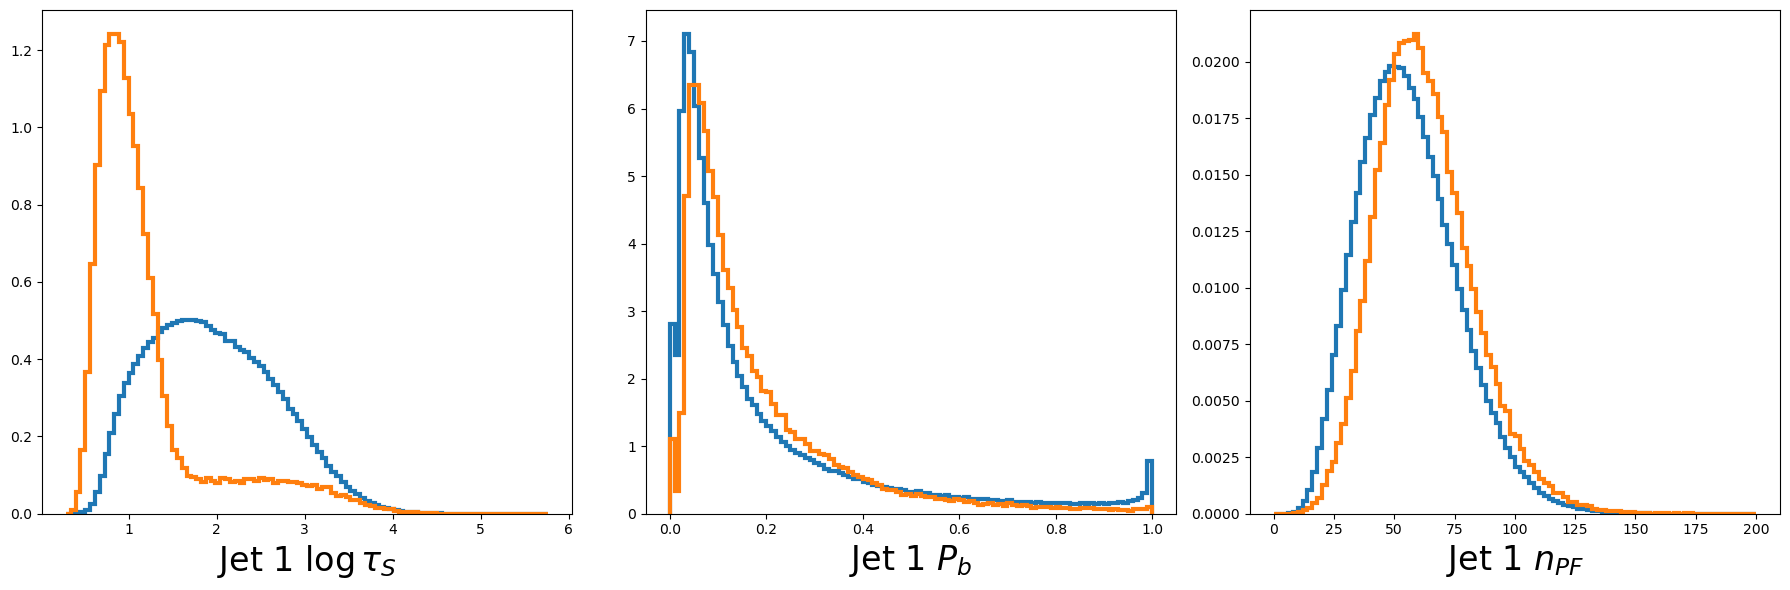

In [10]:
fig,axes = plt.subplots(1,3,figsize=(18,6))
for i in range(4,7):
    plt.sca(axes.flatten()[i-4])
    bins = np.arange(0,202,2) if "npf" in variables[i] else 100
    hb,bins,_ = plt.hist(bkg[:,i],bins=bins,histtype='step',density=True,lw=3,label="Background")
    hs,bins,_ = plt.hist(sig[:,i],bins=bins,histtype='step',density=True,lw=3,label=r"$X \to YY^\prime$ (400, 400) GeV")
    #if i%7==1:
    #    plt.legend(loc='best',fontsize=18)
    plt.xlabel(varnames[i],fontsize=24)
#plt.suptitle("Normalizing Flow Inputs",fontsize=24)
plt.tight_layout()
plt.savefig("plots/misc/nf_inputs_j1_4to7.pdf")

# QUAK spaces no decorr

In [3]:
with h5py.File("lossEvals/BKG.h5","r") as f:
    mjj = f["mjj"][()]
    lb = f["BKG"][()]
    #lb2 = f["BKG_mjjFlat"][()]
    ls = f["XYY3000_Y170_Yp170"][()]
with h5py.File("lossEvals/XYY3000_Y170_Yp170.h5","r") as f:
    mjj_s= f["mjj"][()]
    lb_s = f["BKG"][()]
    #lb2 = f["BKG_mjjFlat"][()]
    ls_s = f["XYY3000_Y170_Yp170"][()]
with h5py.File("lossEvals/YHH5000_H400.h5","r") as f:
    mjj_wp= f["mjj"][()]
    lb_wp = f["BKG"][()]
    #lb2 = f["BKG_mjjFlat"][()]
    ls_wp = f["XYY3000_Y170_Yp170"][()]

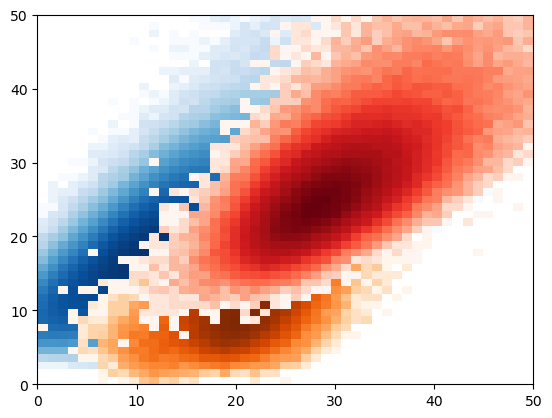

In [31]:
from matplotlib.colors import LogNorm, Normalize
h2=plt.hist2d(lb,ls,bins=np.linspace(0,50,50),norm=LogNorm(),cmap='Blues',alpha=1)
h2=plt.hist2d(lb_s,ls_s,bins=np.linspace(0,50,50),norm=LogNorm(),cmap='Oranges',alpha=1)
h2=plt.hist2d(lb_wp,ls_wp,bins=np.linspace(0,50,50),norm=LogNorm(),cmap='Reds',alpha=1)

(0.0, 50.0)

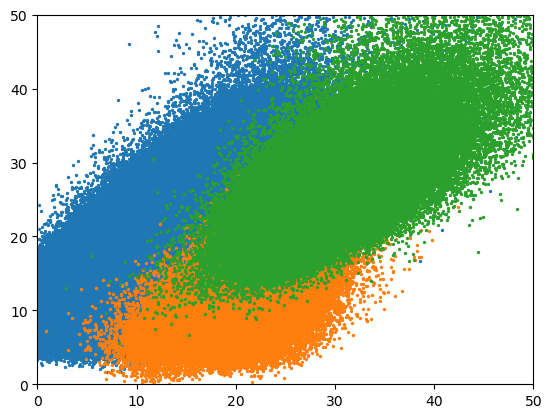

In [35]:
from matplotlib.colors import LogNorm, Normalize
h2=plt.scatter(lb,ls,color="C0",s=2)
h2=plt.scatter(lb_s,ls_s,color="C1",s=2)
h2=plt.scatter(lb_wp,ls_wp,color="C2",s=2)
plt.xlim([0,50])
plt.ylim([0,50])

In [4]:
from sklearn.neighbors import KernelDensity
kde = KernelDensity(kernel='gaussian').fit(np.concatenate([lb[:50000].reshape(-1,1),ls[:50000].reshape(-1,1)],axis=1))
kde_s = KernelDensity(kernel='gaussian').fit(np.concatenate([lb_s.reshape(-1,1),ls_s.reshape(-1,1)],axis=1))
kde_wp = KernelDensity(kernel='gaussian').fit(np.concatenate([lb_wp.reshape(-1,1),ls_wp.reshape(-1,1)],axis=1))

In [12]:
def get_kde(k,bins,**kwargs):
    xx,yy = np.meshgrid(bins,bins)
    toEval = np.vstack([xx.ravel(), yy.ravel()]).T
    density = np.exp(k.score_samples(toEval)).reshape(xx.shape)
    #plt.imshow(density,extent=[bins[0],bins[-1],bins[0],bins[-1]],origin='lower',**kwargs)
    return density

In [22]:
bins=np.linspace(0,50,100)
z = get_kde(kde,bins,cmap="Blues")
zs = get_kde(kde_s,bins,cmap="Oranges")
z_wp = get_kde(kde_wp,bins,cmap="Greens")

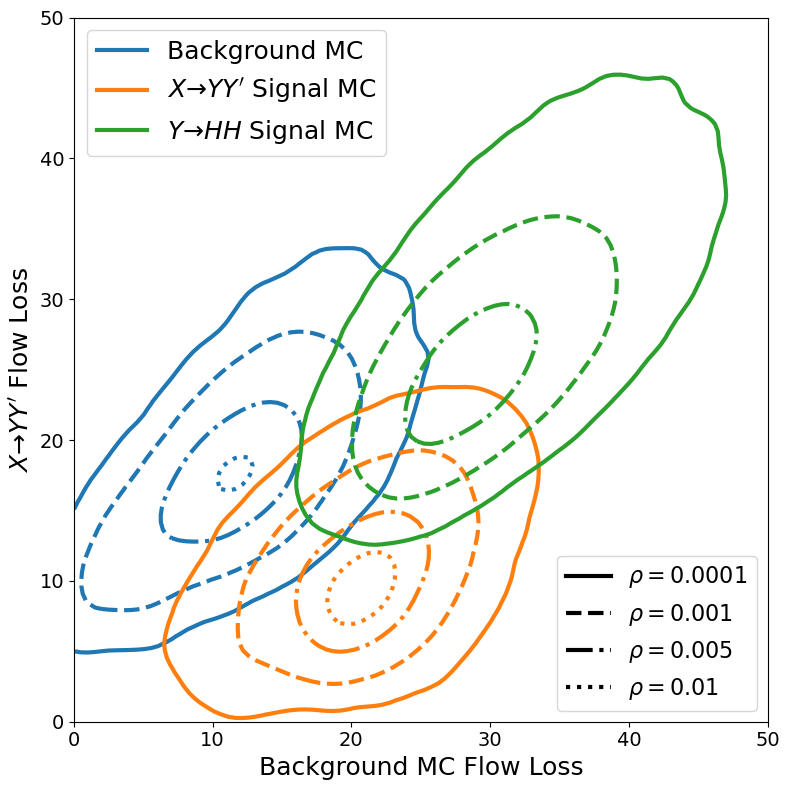

In [36]:
plt.figure(figsize=(8,8))
clevels = [0.0001,0.001,0.005,0.01]
linestyles = ['-','--','-.',':']
plt.contour(z,clevels,extent=[bins.min(),bins.max(),bins.min(),bins.max()],linewidths=3,linestyles=linestyles,colors="C0")
plt.contour(zs,clevels,extent=[bins.min(),bins.max(),bins.min(),bins.max()],linewidths=3,linestyles=linestyles,colors="C1")
plt.contour(z_wp,clevels,extent=[bins.min(),bins.max(),bins.min(),bins.max()],linewidths=3,linestyles=linestyles,colors="C2")

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Background MC Flow Loss",fontsize=18)
plt.ylabel(r"$X \to YY'$ Flow Loss",fontsize=18)
from matplotlib.lines import Line2D
handles = [Line2D([],[],label="Background MC",color="C0",lw=3),
           Line2D([],[],label=r"$X \to YY'$ Signal MC",color="C1",lw=3),
           Line2D([],[],label=r"$Y \to HH$ Signal MC",color="C2",lw=3)]
leg1=plt.legend(handles=handles,loc='upper left',fontsize=18)
plt.gca().add_artist(leg1)
handles = [Line2D([],[],label=r"$\rho = 0.0001$",color="black",lw=3,linestyle='-'),
           Line2D([],[],label=r"$\rho = 0.001$",color="black",lw=3,linestyle='--'),
           Line2D([],[],label=r"$\rho = 0.005$",color="black",lw=3,linestyle='-.'),
           Line2D([],[],label=r"$\rho = 0.01$",color="black",lw=3,linestyle=':')]
plt.legend(handles=handles,loc='lower right',fontsize=16)
#plt.title(r"$M_X = 3$ TeV, $M_Y = M_{Y'} = 170$ GeV, $M")
plt.tight_layout()
plt.savefig("plots/misc/quakspace_sample_yAxis_XYY3000Y170_showXYYandYHH5000.pdf")

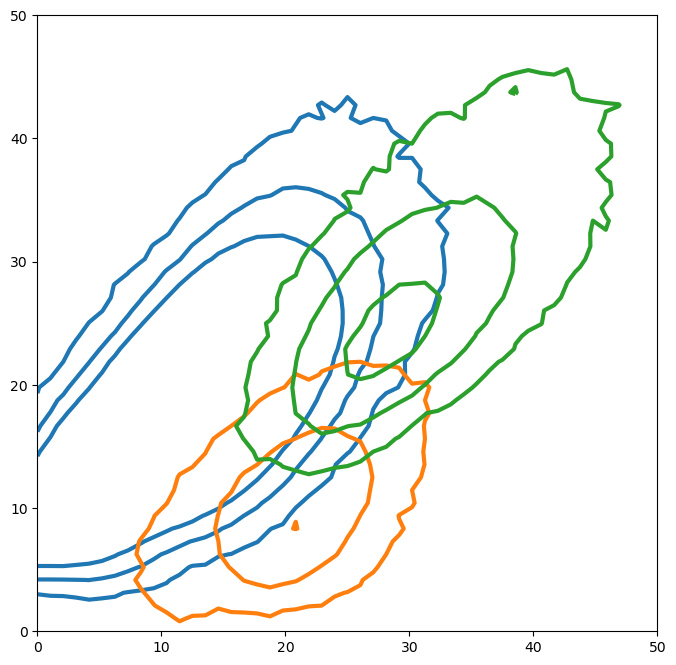

In [10]:
from matplotlib.colors import LogNorm, Normalize
from matplotlib.lines import Line2D
plt.figure(figsize=(8,8))

h2,x,y=np.histogram2d(lb,ls,bins=np.linspace(0,50,50),density=False)
clevels = [0.01,0.1,0.5]
plt.contour(h2.T/(len(x)*len(y)),clevels,extent=[x.min(),x.max(),y.min(),y.max()],linewidths=3,colors="C0")


h2,x,y=np.histogram2d(lb_s,ls_s,bins=np.linspace(0,50,50),density=False)
clevels = [0.01,0.1,0.5]
plt.contour(h2.T/(len(x)*len(y)),clevels,extent=[x.min(),x.max(),y.min(),y.max()],linewidths=3,colors="C1")

h2,x,y=np.histogram2d(lb_wp,ls_wp,bins=np.linspace(0,50,50),density=False)
clevels = [0.01,0.1,0.5]
plt.contour(h2.T/(len(x)*len(y)),clevels,extent=[x.min(),x.max(),y.min(),y.max()],linewidths=3,colors="C2")

#plt.legend(handles)

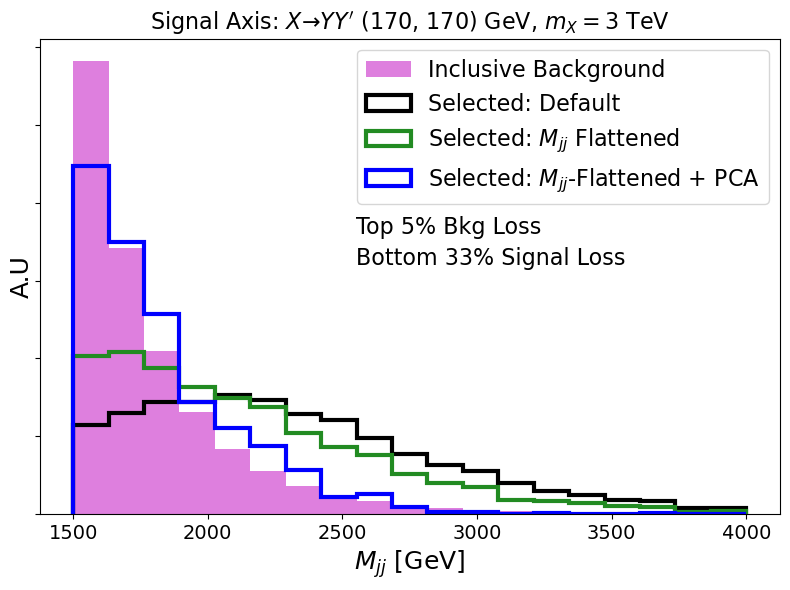

In [48]:
with h5py.File("lossEvals/BKG.h5","r") as f:
    mjj = f["mjj"][()]
    lb = f["BKG"][()]
    lb_flat = f["BKG_mjjFlat"][()]
    ls = f["XYY3000_Y170_Yp170"][()]
    
with h5py.File("lossEvals_pcaDecorr_boxCox/BKG.h5","r") as f:
    mjj_pca = f["mjj"][()]
    lb_flat_pca = f["BKG_mjjFlat"][()]
    ls_pca = f["XYY3000_Y170_Yp170"][()]
    
bins = np.linspace(1500,4000,20)
pb = 0.95
ps = 0.33

plt.figure(figsize=(8,6))

plt.hist(mjj_pca,histtype='stepfilled',density=True,bins=bins,lw=3,color='m',alpha=0.5,label="Inclusive Background")

qb = np.quantile(lb,pb)
qs = np.quantile(ls,ps)
cut = (lb>qb)&(ls<qs)
plt.hist(mjj[cut],histtype='step',density=True,bins=bins,lw=3,color='black',label="Selected: Default")

qb = np.quantile(lb_flat,pb)
qs = np.quantile(ls,ps)
cut = (lb_flat>qb)&(ls<qs)
plt.hist(mjj[cut],histtype='step',density=True,bins=bins,lw=3,color='forestgreen',label=r"Selected: $M_{jj}$ Flattened")

qb = np.quantile(lb_flat_pca,pb)
qs = np.quantile(ls_pca,ps)
cut = (lb_flat_pca>qb)&(ls_pca<qs)
plt.hist(mjj_pca[cut],histtype='step',density=True,bins=bins,lw=3,color='blue',label=r"Selected: $M_{jj}$-Flattened + PCA")

#plt.yscale('log')
plt.xlabel(r"$M_{jj}$ [GeV]",fontsize=18)
plt.xticks(fontsize=14)
plt.legend(loc='upper right',fontsize=16)
plt.gca().yaxis.set_tick_params(labelleft=False)
plt.text(2550,0.0018,"Top 5% Bkg Loss",fontsize=16)
plt.text(2550,0.0016,"Bottom 33% Signal Loss",fontsize=16)
plt.title(r"Signal Axis: $X \to YY'$ (170, 170) GeV, $m_X = 3$ TeV",fontsize=16)
plt.ylabel("A.U",fontsize=18)
#plt.savefig("plots/misc/mjj_example_defaultOnly.pdf",bbox_inches='tight')
#plt.savefig("plots/misc/mjj_example_flatTraining.pdf",bbox_inches='tight')
plt.tight_layout()
plt.savefig("plots/misc/mjj_example_flatTraining_pca.pdf",bbox_inches='tight')


# QUAK Spaces decorr

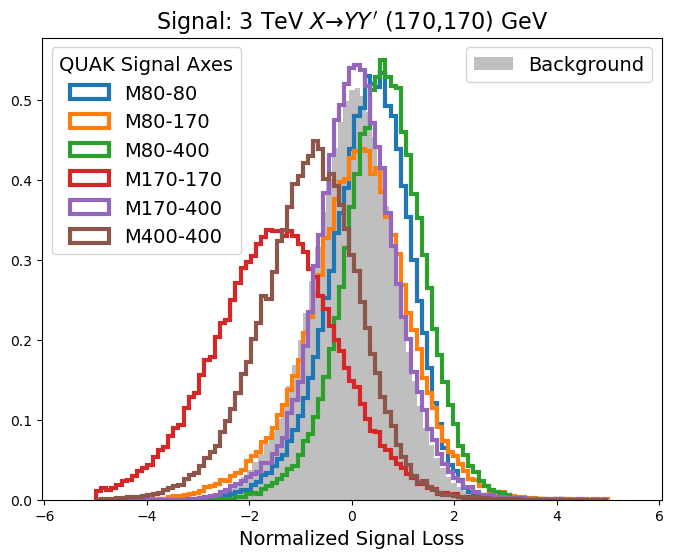

In [2]:
bkg_axis = "BKG_mjjFlat"
sig_axes = ["M80-80","M80-170","M80-400","M170-170","M170-400","M400-400"]

with h5py.File("lossEvals_pcaDecorr_boxCox/BKG.h5","r") as f:
    lb_b = f[bkg_axis][()]
    ls_b = np.concatenate([f[s][()].reshape(-1,1) for s in sig_axes],axis=1)
    
with h5py.File("lossEvals_pcaDecorr_boxCox/XYY3000_Y170_Yp170.h5","r") as f:
    lb_s = f[bkg_axis][()]
    ls_s = np.concatenate([f[s][()].reshape(-1,1) for s in sig_axes],axis=1)

from matplotlib.patches import Patch
plt.figure(figsize=(8,6))
hbkg = plt.hist(np.mean(ls_b,axis=1),bins=np.linspace(-5.5,5.5,100),
                histtype='stepfilled',density=True,alpha=0.5,color=f"gray")
for i in range(ls_b.shape[1]):
    h = plt.hist(ls_s[:,i],bins=np.linspace(-5,5,100),lw=3,histtype='step',density=True,color=f"C{i}",label=sig_axes[i])    
leg1=plt.legend(loc='upper left',fontsize=14,title="QUAK Signal Axes",title_fontsize=14)
plt.gca().add_artist(leg1)
plt.legend(handles=[Patch(facecolor='gray',alpha=0.5,label="Background")],loc='upper right',fontsize=14)
plt.title(r"Signal: 3 TeV $X \to YY^\prime$ (170,170) GeV",fontsize=16)
plt.xlabel("Normalized Signal Loss",fontsize=14)
plt.savefig("plots/misc/losses_massbins_XYY3000_Y170_Yp170.pdf",bbox_inches='tight')

In [341]:
bkg_axis = "BKG_mjjFlat"
sig_axes = ["M80-80","M80-170","M80-400","M170-170","M170-400","M400-400"]

with h5py.File("lossEvals_pcaDecorr_boxCox/BKG.h5","r") as f:
    lb_b = f[bkg_axis][()]
    ls_b = np.concatenate([f[s][()].reshape(-1,1) for s in sig_axes],axis=1)
    
with h5py.File("lossEvals_pcaDecorr_boxCox/XYY3000_Y170_Yp170.h5","r") as f:
    lb_s = f[bkg_axis][()]
    ls_s = np.concatenate([f[s][()].reshape(-1,1) for s in sig_axes],axis=1)
    
with h5py.File("lossEvals_pcaDecorr_boxCox/Wp3000_B400_T170.h5","r") as f:
    lb_wp = f[bkg_axis][()]
    ls_wp = np.concatenate([f[s][()].reshape(-1,1) for s in sig_axes],axis=1)

with h5py.File("lossEvals_pcaDecorr_boxCox/YHH3000_H400.h5","r") as f:
    lb_yh = f[bkg_axis][()]
    ls_yh = np.concatenate([f[s][()].reshape(-1,1) for s in sig_axes],axis=1)

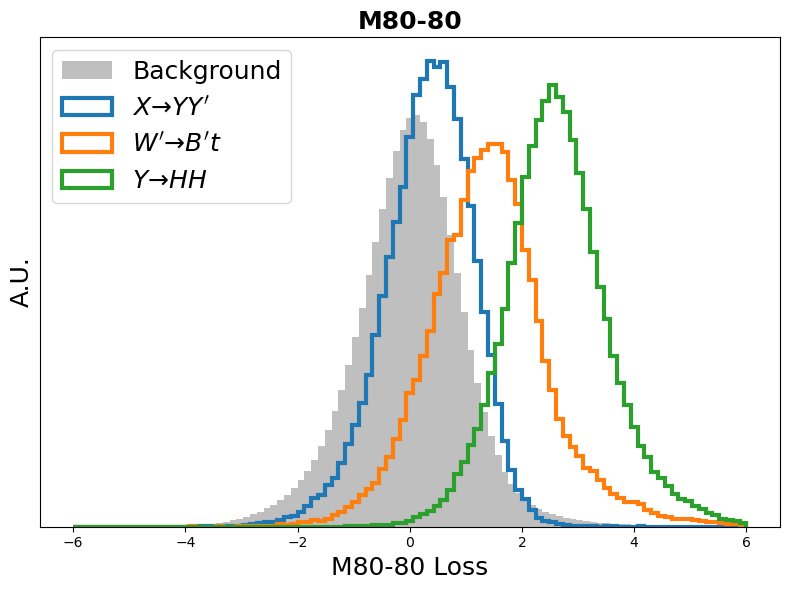

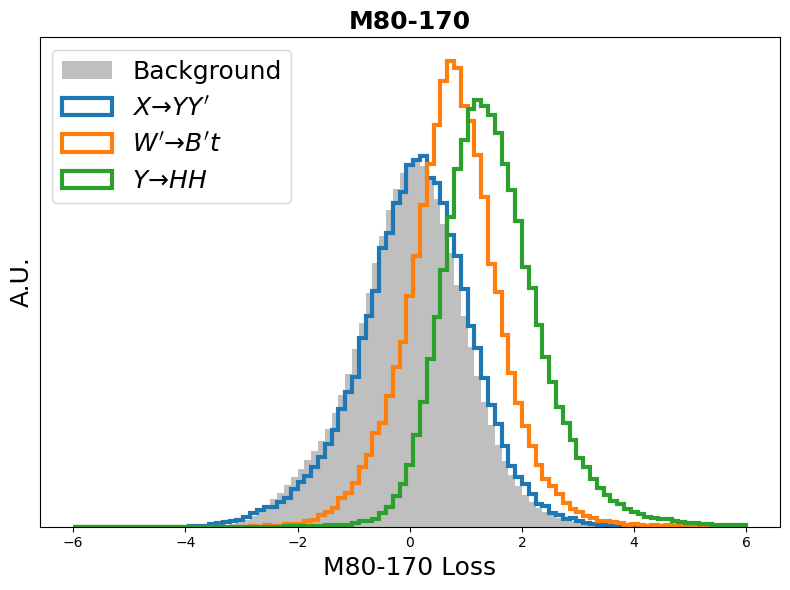

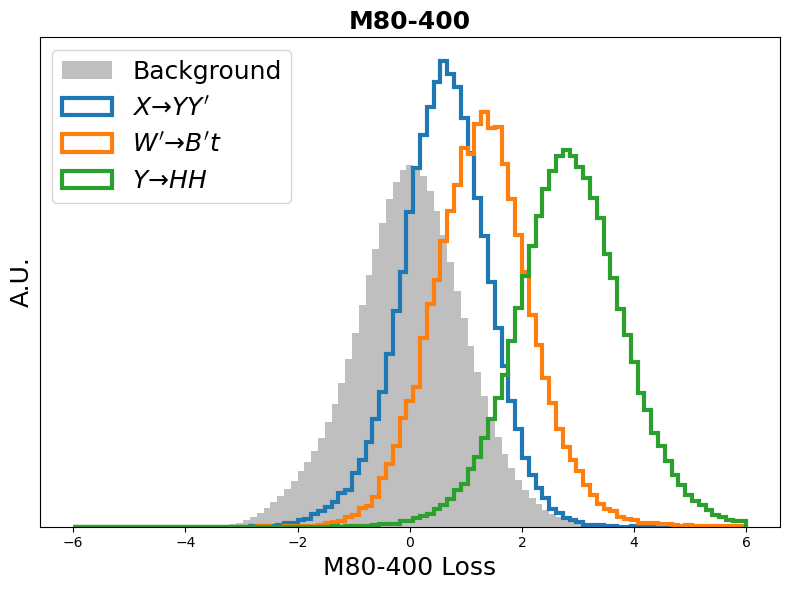

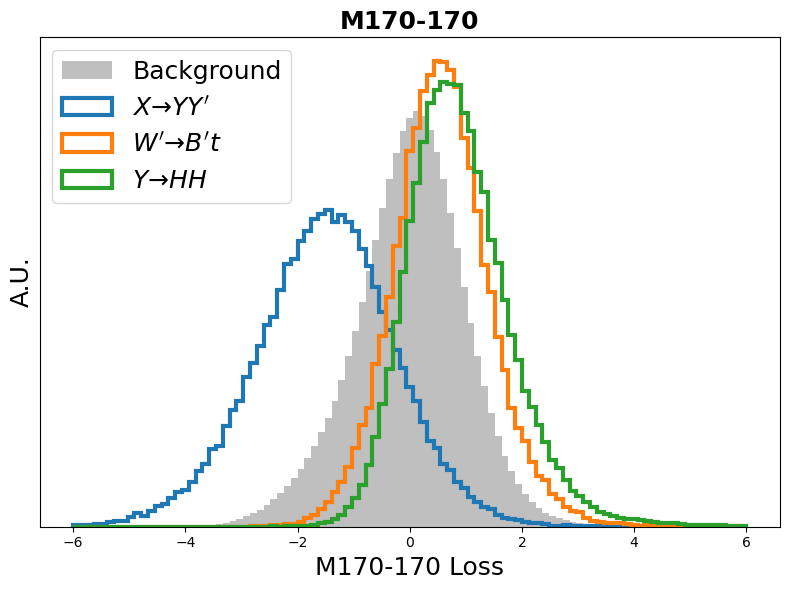

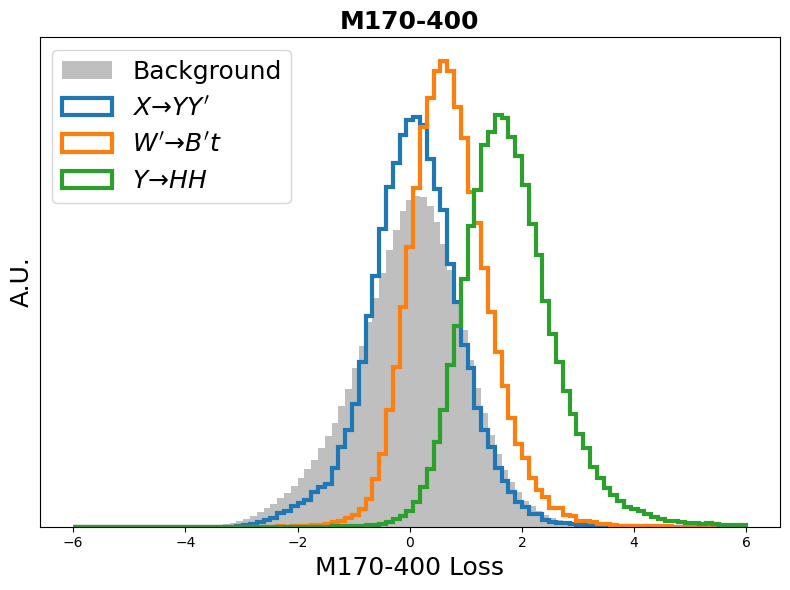

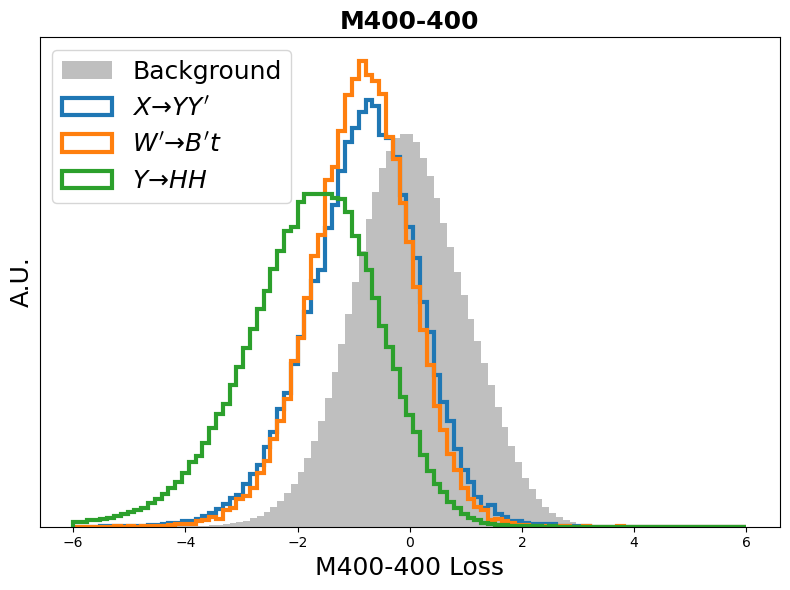

In [347]:
from matplotlib.patches import Patch
for i,ax in enumerate(sig_axes):
    plt.figure(figsize=(8,6))
    bins=np.linspace(-6,6,100)
    hbkg = plt.hist(ls_b[:,i],bins=bins,histtype='stepfilled',density=True,alpha=0.5,color=f"gray",label="Background")
    h = plt.hist(ls_s[:,i],bins=bins,lw=3,histtype='step',density=True,color=f"C0",label=r"$X \to YY'$")
    h = plt.hist(ls_wp[:,i],bins=bins,lw=3,histtype='step',density=True,color=f"C1",label=r"$W'\to B't$")
    h = plt.hist(ls_yh[:,i],bins=bins,lw=3,histtype='step',density=True,color=f"C2",label=r"$Y \to HH$")
    plt.legend(loc='upper left',fontsize=18)
    plt.title(f"{ax}",fontsize=18,fontweight='bold')
    plt.xlabel(f"{ax} Loss",fontsize=18)
    plt.yticks([])
    plt.ylabel("A.U.",fontsize=18)
    plt.tight_layout()
    plt.savefig(f"plots/misc/example_massBinLosses_{ax}.pdf",bbox_inches='tight')

Text(0.5, 1.0, 'Raw Losses')

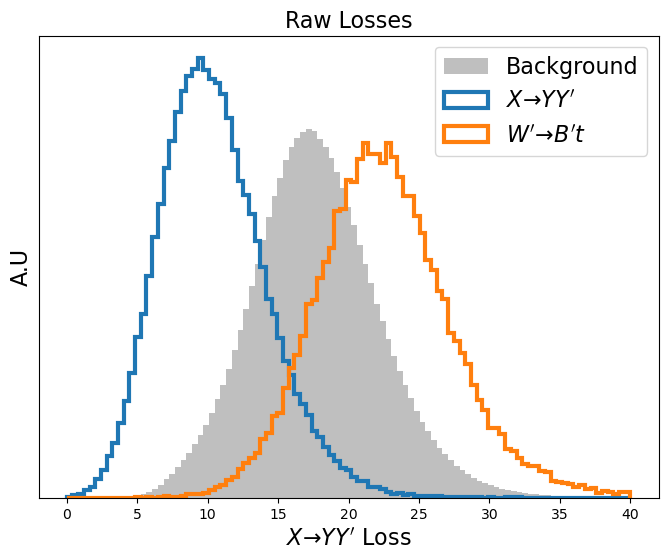

In [67]:
bkg_axis = "BKG_mjjFlat"
sig_axes = ["XYY3000_Y170_Yp170"]

with h5py.File("lossEvals/BKG.h5","r") as f:
    lb_b = f[bkg_axis][()]
    ls_b = np.concatenate([f[s][()].reshape(-1,1) for s in sig_axes],axis=1)
    
with h5py.File("lossEvals/XYY3000_Y170_Yp170.h5","r") as f:
    lb_s = f[bkg_axis][()]
    ls_s = np.concatenate([f[s][()].reshape(-1,1) for s in sig_axes],axis=1)
    
with h5py.File("lossEvals/Wp3000_B400_T170.h5","r") as f:
    lb_wp = f[bkg_axis][()]
    ls_wp = np.concatenate([f[s][()].reshape(-1,1) for s in sig_axes],axis=1)

from matplotlib.patches import Patch
plt.figure(figsize=(8,6))
bins=np.linspace(0,40,100)
hbkg = plt.hist(np.mean(ls_b,axis=1),bins=bins,
                histtype='stepfilled',density=True,alpha=0.5,color=f"gray",label="Background")
h = plt.hist(ls_s[:,0],bins=bins,lw=3,histtype='step',density=True,color=f"C0",label=r"$X \to YY'$")
h = plt.hist(ls_wp[:,0],bins=bins,lw=3,histtype='step',density=True,color=f"C1",label=r"$W' \to B't$")
plt.legend(loc='upper right',fontsize=16)
plt.xlabel(r"$X \to YY'$ Loss",fontsize=16)
plt.yticks([])
plt.ylabel("A.U",fontsize=16)
plt.title("Raw Losses",fontsize=16)
#plt.savefig("plots/misc/losses_massbins_XYY3000_Y170_Yp170.pdf",bbox_inches='tight')

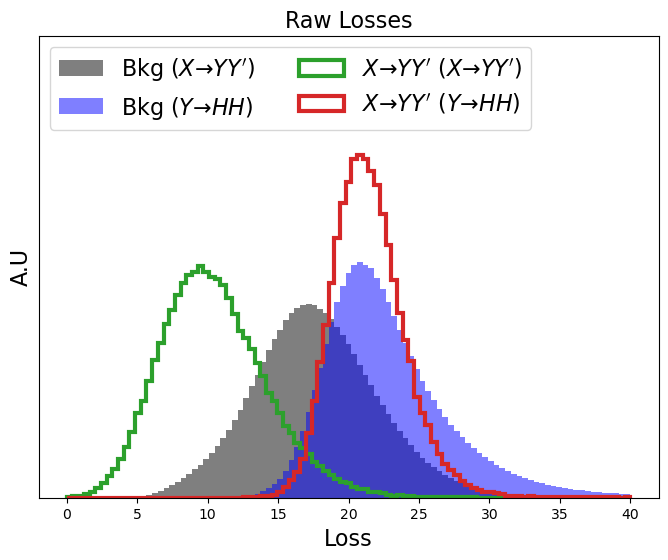

In [105]:
bkg_axis = "BKG_mjjFlat"
sig_axes = ["XYY3000_Y170_Yp170","YHH3000_H400"]

with h5py.File("lossEvals/BKG.h5","r") as f:
    lb_b = f[bkg_axis][()]
    ls_b = np.concatenate([f[s][()].reshape(-1,1) for s in sig_axes],axis=1)
    
with h5py.File("lossEvals/XYY3000_Y170_Yp170.h5","r") as f:
    lb_s = f[bkg_axis][()]
    ls_s = np.concatenate([f[s][()].reshape(-1,1) for s in sig_axes],axis=1)
    
with h5py.File("lossEvals/Wp3000_B400_T170.h5","r") as f:
    lb_wp = f[bkg_axis][()]
    ls_wp = np.concatenate([f[s][()].reshape(-1,1) for s in sig_axes],axis=1)

from matplotlib.patches import Patch
plt.figure(figsize=(8,6))
bins=np.linspace(0,40,100)
hbkg = plt.hist(ls_b[:,0],bins=bins,
                histtype='stepfilled',alpha=0.5,density=True,color=f"black",label=r"Bkg ($X \to YY'$)",lw=3)
hbkg = plt.hist(ls_b[:,1],bins=bins,
                histtype='stepfilled',alpha=0.5,density=True,color=f"blue",label=r"Bkg ($Y \to HH$)",linestyle='--',lw=3)
h = plt.hist(ls_s[:,0],bins=bins,lw=3,histtype='step',density=True,color=f"C2",label=r"$X \to YY'$ ($X \to YY'$)")
h = plt.hist(ls_s[:,1],bins=bins,lw=3,histtype='step',density=True,color=f"C3",label=r"$X \to YY'$ ($Y \to HH$)")
plt.legend(loc='upper left',fontsize=16,ncol=2)
plt.xlabel(r"Loss",fontsize=16)
plt.yticks([])
plt.ylabel("A.U",fontsize=16)
plt.title("Raw Losses",fontsize=16)
plt.ylim([0,0.225])
#plt.yscale('log')
plt.savefig("plots/misc/raw_losses_showScaleDifference_example.pdf",bbox_inches='tight')

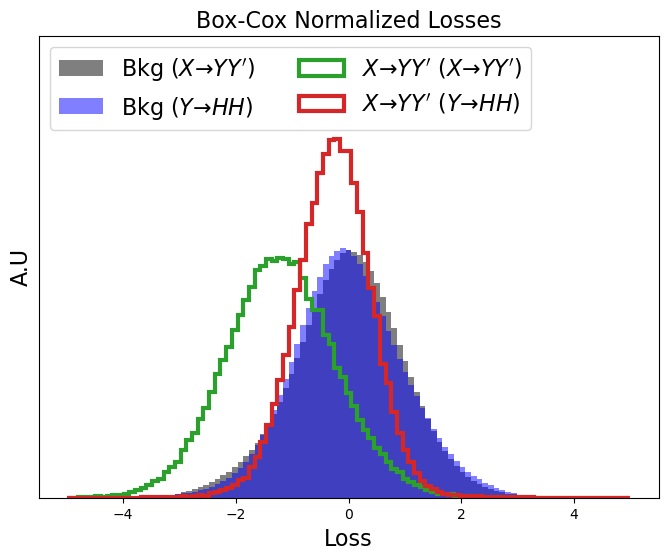

In [107]:
bkg_axis = "BKG_mjjFlat"
sig_axes = ["XYY3000_Y170_Yp170","YHH3000_H400"]

with h5py.File("lossEvals_pcaDecorr_boxCox/BKG.h5","r") as f:
    lb_b = f[bkg_axis][()]
    ls_b = np.concatenate([f[s][()].reshape(-1,1) for s in sig_axes],axis=1)
    
with h5py.File("lossEvals_pcaDecorr_boxCox/XYY3000_Y170_Yp170.h5","r") as f:
    lb_s = f[bkg_axis][()]
    ls_s = np.concatenate([f[s][()].reshape(-1,1) for s in sig_axes],axis=1)

from matplotlib.patches import Patch
plt.figure(figsize=(8,6))
bins=np.linspace(-5,5,100)
hbkg = plt.hist(ls_b[:,0],bins=bins,
                histtype='stepfilled',alpha=0.5,density=True,color=f"black",label=r"Bkg ($X \to YY'$)",lw=3)
hbkg = plt.hist(ls_b[:,1],bins=bins,
                histtype='stepfilled',alpha=0.5,density=True,color=f"blue",label=r"Bkg ($Y \to HH$)",linestyle='--',lw=3)
h = plt.hist(ls_s[:,0],bins=bins,lw=3,histtype='step',density=True,color=f"C2",label=r"$X \to YY'$ ($X \to YY'$)")
h = plt.hist(ls_s[:,1],bins=bins,lw=3,histtype='step',density=True,color=f"C3",label=r"$X \to YY'$ ($Y \to HH$)")
plt.legend(loc='upper left',fontsize=16,ncol=2)
plt.xlabel(r"Loss",fontsize=16)
plt.yticks([])
plt.ylabel("A.U",fontsize=16)
plt.title("Box-Cox Normalized Losses",fontsize=16)
plt.ylim([0,0.8])
#plt.yscale('log')
plt.savefig("plots/misc/boxCoxNorm_losses_example.pdf",bbox_inches='tight')

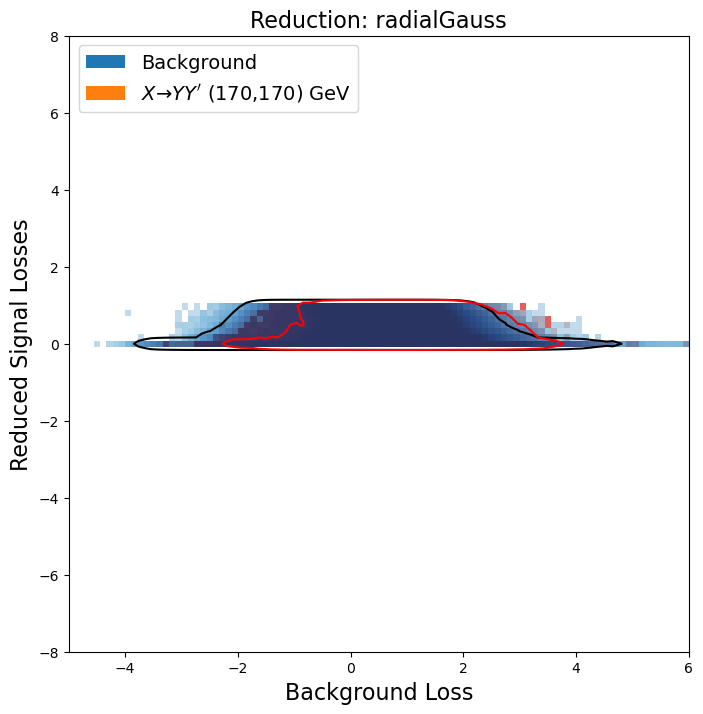

In [30]:
from quakSpaceMaker_v2 import reductions
from matplotlib.colors import LogNorm, Normalize
plt.figure(figsize=(8,8))
xbins = np.linspace(-5,6,100)
ybins = np.linspace(-8,8,100)
#xbins,ybins = 100,100
qlevels = [0.25]
norm = "radialGauss"
slb = reductions[norm].transform(ls_b)
sls = reductions[norm].transform(ls_s)


cts,xbins,ybins = np.histogram2d(lb_b, slb, bins=(xbins,ybins))
cts = cts/len(lb_b)
qb = np.quantile(cts.flatten()[cts.flatten()>0],qlevels)

cts_s,xbins,ybins = np.histogram2d(lb_s, sls, bins=(xbins,ybins))
cts_s = cts_s/len(lb_s)
qs = np.quantile(cts_s.flatten()[cts_s.flatten()>0],qlevels)

plt.xlim(xbins[0],xbins[-1])
plt.ylim(ybins[0],ybins[-1])
hnorm=LogNorm(vmin=min(np.min(cts_s[cts_s>0]),np.min(cts[cts>0])),
               vmax=max(cts_s.max(),cts.max()))
extent = [xbins[0],xbins[-1],ybins[0],ybins[-1]]
#plt.imshow(cts_s.T,extent=extent,origin='lower',cmap="Oranges",alpha=1,norm=norm,aspect='auto')
#plt.imshow(cts.T,extent=extent,origin='lower',cmap="Blues",alpha=0.5,norm=norm,aspect='auto')

#plt.scatter(lb_s[:],sls[:],s=2,color="C1")
#plt.scatter(lb_b[:],slb[:],s=2,color="C0")
plt.contour(cts.T, extent=[xbins.min(),xbins.max(),ybins.min(),ybins.max()], 
            colors='black', alpha=1,levels=qb)
plt.contour(cts_s.T, extent=[xbins.min(),xbins.max(),ybins.min(),ybins.max()], colors='red', 
            alpha=1,levels=qs)
plt.hist2d(lb_s[:],sls[:],cmap="Reds",label=r"$X \to YY^\prime$ (170,170) GeV",
           bins=(xbins,ybins),alpha=0.75,density=True,norm=hnorm)
plt.hist2d(lb_b,slb,cmap="Blues",label="Background",
           bins=(xbins,ybins),alpha=0.75,density=True,norm=hnorm)
plt.xlabel("Background Loss",fontsize=16)
plt.ylabel("Reduced Signal Losses",fontsize=16)
plt.title(f"Reduction: {norm}",fontsize=16)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='C0',label='Background'),
                   Patch(facecolor='C1',label=r'$X \to YY^\prime$ (170,170) GeV')]
plt.legend(handles=legend_elements, loc='upper left',fontsize=14)

plt.savefig(f"plots/misc/quakSpace_{norm}.pdf")

# Sample QUAK space binning

In [3]:
bkg_axis = "BKG_mjjFlat"
sig_axes = ["M80-80","M80-170","M80-400","M170-170","M170-400","M400-400"]

with h5py.File("lossEvals_pcaDecorr_boxCox/BKG.h5","r") as f:
    mjj = f["mjj"][()]
    lb_b = f[bkg_axis][()]
    ls_b = np.concatenate([f[s][()].reshape(-1,1) for s in sig_axes],axis=1)
    
with h5py.File("lossEvals_pcaDecorr_boxCox/XYY3000_Y170_Yp170.h5","r") as f:
    mjj_s = f['mjj'][()]
    lb_s = f[bkg_axis][()]
    ls_s = np.concatenate([f[s][()].reshape(-1,1) for s in sig_axes],axis=1)
    
with h5py.File("lossEvals_pcaDecorr_boxCox/YHH3000_H400.h5","r") as f:
    mjj_yh = f['mjj'][()]
    lb_yh = f[bkg_axis][()]
    ls_yh = np.concatenate([f[s][()].reshape(-1,1) for s in sig_axes],axis=1)
    
with h5py.File("lossEvals_pcaDecorr_boxCox/Wp3000_B400_T170.h5","r") as f:
    mjj_wp = f['mjj'][()]
    lb_wp = f[bkg_axis][()]
    ls_wp = np.concatenate([f[s][()].reshape(-1,1) for s in sig_axes],axis=1)

In [4]:
from quakSpaceMaker_v2 import reductions
ls_b_reduc_raw = reductions["signedL5"].transform(ls_b)
ls_s_reduc_raw = reductions["signedL5"].transform(ls_s)
ls_wp_reduc_raw = reductions["signedL5"].transform(ls_wp)
ls_yh_reduc_raw = reductions["signedL5"].transform(ls_yh)

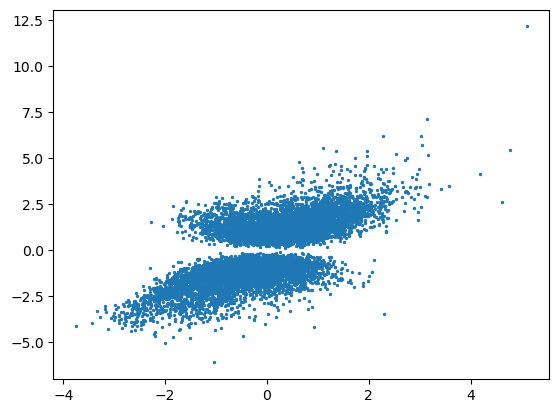

In [5]:
plt.scatter(lb_b[:10000],ls_b_reduc_raw[:10000],s=2)

In [10]:
binsx = np.linspace(-6,6,150)
binsy = np.linspace(-10,10,150)
xx,yy = np.meshgrid((binsx[:-1]+binsx[1:])/2,(binsy[:-1]+binsy[1:])/2)
h,b1,b2 = np.histogram2d(lb_b,ls_b_reduc_raw,bins=(binsx,binsy),density=True)
h_s,b1,b2 = np.histogram2d(lb_s,ls_s_reduc_raw,bins=(binsx,binsy),density=True)
h_wp,b1,b2 = np.histogram2d(lb_wp,ls_wp_reduc_raw,bins=(binsx,binsy),density=True)
h_yh,b1,b2 = np.histogram2d(lb_yh,ls_yh_reduc_raw,bins=(binsx,binsy),density=True)

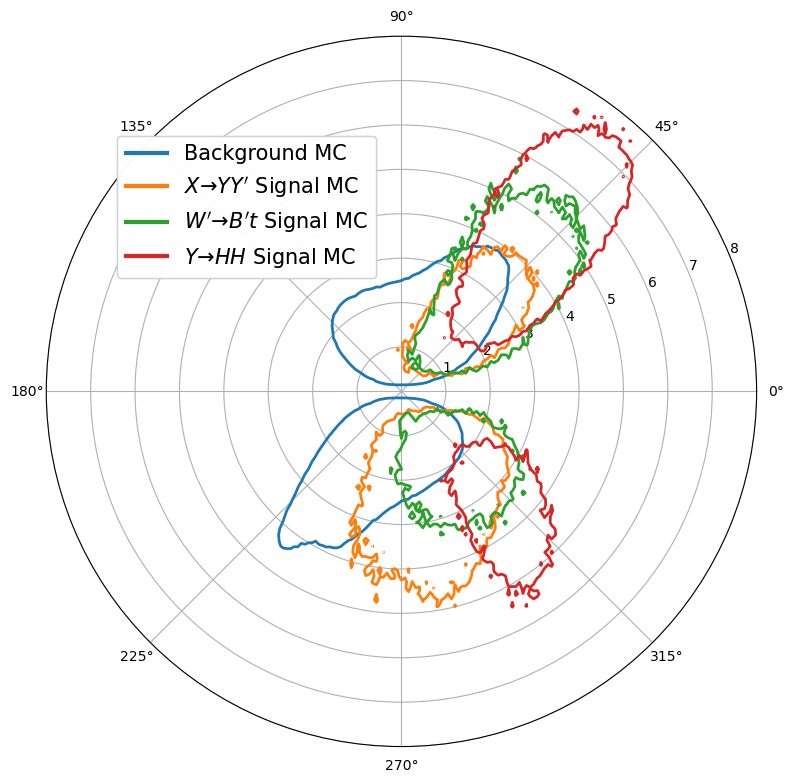

In [43]:
fig, ax = plt.subplots(figsize=(8,8),subplot_kw={'projection': 'polar'})
#levels = [0.01,0.02,0.05,0.08]
#linestyles = ['-','--','-.',':']
levels = [0.01]
linestyles = ['-']
plt.contour(np.arctan2(yy,xx),np.sqrt(xx**2+yy**2),h.T,levels,linewidths=2,colors='C0',linestyles=linestyles,alpha=1)
plt.contour(np.arctan2(yy,xx),np.sqrt(xx**2+yy**2),h_s.T,levels,linewidths=2,colors='C1',linestyles=linestyles,alpha=1)
plt.contour(np.arctan2(yy,xx),np.sqrt(xx**2+yy**2),h_wp.T,levels,linewidths=2,colors='C2',linestyles=linestyles,alpha=1)
plt.contour(np.arctan2(yy,xx),np.sqrt(xx**2+yy**2),h_yh.T,levels,linewidths=2,colors='C3',linestyles=linestyles,alpha=1)

#plt.axvline(minangle,color='black',linestyle='--',lw=3)
#plt.axvline(maxAngle,color='black',linestyle='--',lw=3)
#plt.gca().set_thetamin(-30)
#plt.gca().set_thetamax(95)
plt.gca().set_rmax(8)

from matplotlib.lines import Line2D
handles = [Line2D([],[],label="Background MC",color="C0",lw=3),
           Line2D([],[],label=r"$X \to YY'$ Signal MC",color="C1",lw=3),
           Line2D([],[],label=r"$W' \to B't$ Signal MC",color="C2",lw=3),
           Line2D([],[],label=r"$Y \to HH$ Signal MC",color="C3",lw=3)]
leg1 = plt.legend(handles=handles,loc=(0.1,0.66),fontsize=15)
#leg1 = plt.legend(handles=handles,loc=(0.01,0.5),fontsize=15)
plt.gca().add_artist(leg1)
#handles = [Line2D([],[],label="Selection Wedge",lw=3,linestyle='--',color='k')]
#plt.legend(handles=handles,loc=(0.52,0.95),fontsize=18)
plt.tight_layout()
plt.savefig('plots/misc/example_polar_quakSpace_signedL5massBins_noDecorr.pdf')

In [44]:
from sklearn.linear_model import LinearRegression
fit_bkg = LinearRegression().fit(lb_b.reshape(-1,1),ls_b)
ls_b_corr = ls_b - fit_bkg.predict(lb_b.reshape(-1,1))
ls_s_corr = ls_s - fit_bkg.predict(lb_s.reshape(-1,1))
ls_wp_corr = ls_wp - fit_bkg.predict(lb_wp.reshape(-1,1))
ls_yh_corr = ls_yh - fit_bkg.predict(lb_yh.reshape(-1,1))

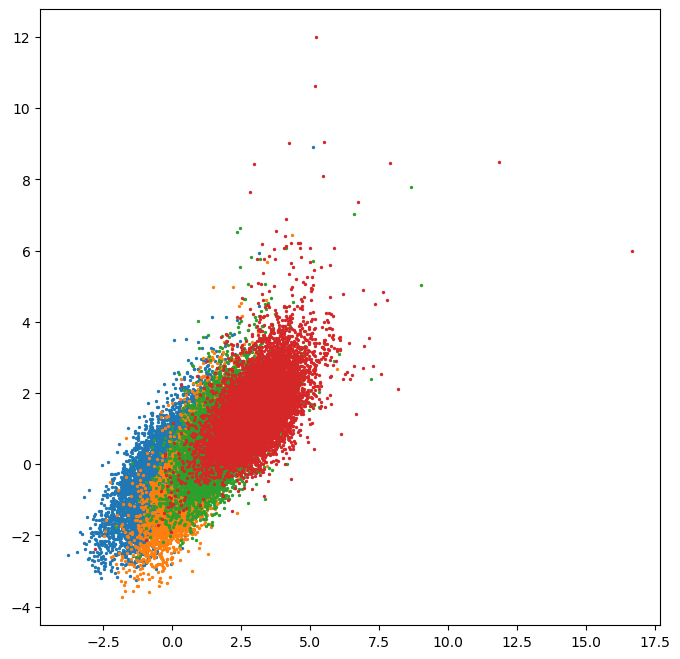

In [14]:
plt.figure(figsize=(8,8))
plt.scatter(lb_b[:10000],ls_b[:10000,1],s=2)
plt.scatter(lb_s[:10000],ls_s[:10000,1],s=2)
plt.scatter(lb_wp[:10000],ls_wp[:10000,1],s=2)
plt.scatter(lb_yh[:10000],ls_yh[:10000,1],s=2)

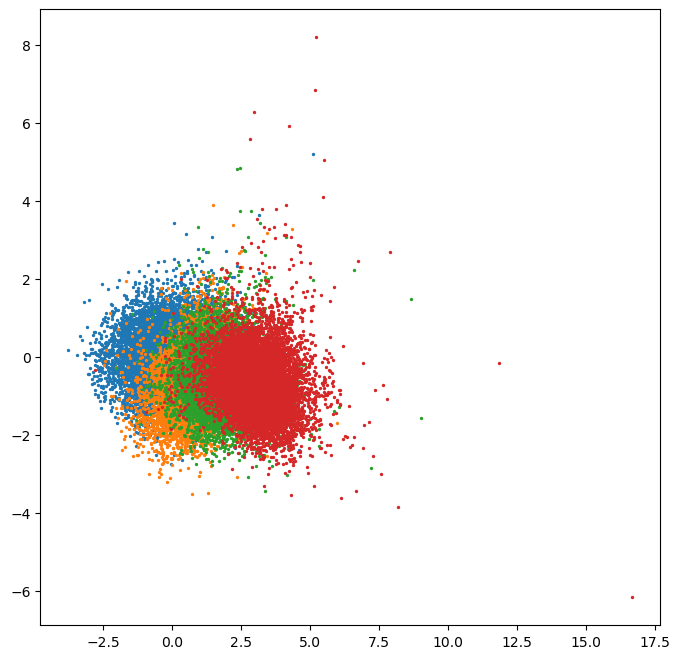

In [15]:
plt.figure(figsize=(8,8))
plt.scatter(lb_b[:10000],ls_b_corr[:10000,1],s=2)
plt.scatter(lb_s[:10000],ls_s_corr[:10000,1],s=2)
plt.scatter(lb_wp[:10000],ls_wp_corr[:10000,1],s=2)
plt.scatter(lb_yh[:10000],ls_yh_corr[:10000,1],s=2)

In [69]:
from quakSpaceMaker_v2 import reductions
ls_b_reduc = reductions["signedL5"].transform(ls_b_corr)
ls_s_reduc = reductions["signedL5"].transform(ls_s_corr)
ls_wp_reduc = reductions["signedL5"].transform(ls_wp_corr)
ls_yh_reduc = reductions["signedL5"].transform(ls_yh_corr)

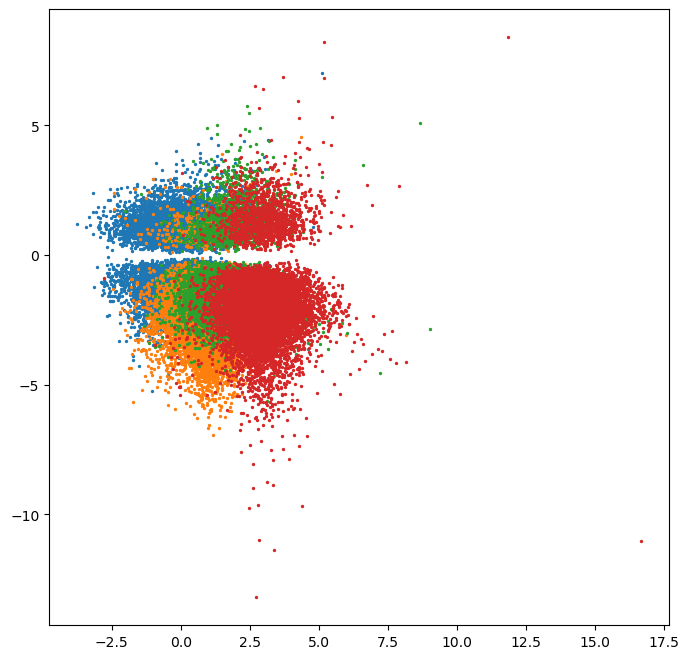

In [70]:
plt.figure(figsize=(8,8))
plt.scatter(lb_b[:10000],ls_b_reduc[:10000],s=2)
plt.scatter(lb_s[:10000],ls_s_reduc[:10000],s=2)
plt.scatter(lb_wp[:10000],ls_wp_reduc[:10000],s=2)
plt.scatter(lb_yh[:10000],ls_yh_reduc[:10000],s=2)

In [71]:
bkgCut = -1.
sidebandsize = 500

loss1 = ls_b_reduc
loss2 = lb_b
mass = mjj
loss1_s = ls_s_reduc
loss2_s = lb_s
mass_s = mjj_s
loss1_wp = ls_wp_reduc
loss2_wp = lb_wp
mass_wp = mjj_wp
loss1_yh = ls_yh_reduc
loss2_yh = lb_yh
mass_yh = mjj_yh

cut = (loss2>bkgCut)&(mass>1460)
mass = mass[cut]
loss1 = loss1[cut]
loss2 = loss2[cut]-bkgCut

cut_s = (loss2_s>bkgCut)&(mass_s>1460)
mass_s = mass_s[cut_s]
loss1_s = loss1_s[cut_s]
loss2_s = loss2_s[cut_s]-bkgCut

cut_wp = (loss2_wp>bkgCut)&(mass_wp>1460)
mass_wp = mass_wp[cut_wp]
loss1_wp = loss1_wp[cut_wp]
loss2_wp = loss2_wp[cut_wp]-bkgCut

cut_yh = (loss2_yh>bkgCut)&(mass_yh>1460)
mass_yh = mass_yh[cut_yh]
loss1_yh = loss1_yh[cut_yh]
loss2_yh = loss2_yh[cut_yh]-bkgCut

sigOffset = np.average(loss1) - 9
loss1 = loss1 - sigOffset
loss1_s = loss1_s - sigOffset
loss1_wp = loss1_wp - sigOffset
loss1_yh = loss1_yh - sigOffset

sr = (mass>2600)&(mass<3200)
sr_s = (mass_s>2600)&(mass_s<3200)
sr_wp = (mass_wp>2600)&(mass_wp<3200)
sr_yh = (mass_yh>2600)&(mass_yh<3200)

sb = ((mass>(2600-sidebandsize)) & (mass<2600)) | ((mass>3200) & (mass<(3200+sidebandsize)))
sb_s = ((mass_s>(2600-sidebandsize)) & (mass_s<2600)) | ((mass_s>3200) & (mass_s<(3200+sidebandsize)))
sb_wp = ((mass_wp>(2600-sidebandsize)) & (mass_wp<2600)) | ((mass_wp>3200) & (mass_wp<(3200+sidebandsize)))
sb_yh = ((mass_yh>(2600-sidebandsize)) & (mass_yh<2600)) | ((mass_yh>3200) & (mass_yh<(3200+sidebandsize)))

In [72]:
minangle = -.1*np.pi
angularbincount = 25
maxRad = 10
radBins = 20
bkgCut = -1.
windowOffset = 100

for a in range(6):
    rbins = np.linspace(0, maxRad, radBins)
    abins = np.linspace(minangle,(0.4 + 0.02*a)*np.pi, angularbincount+a)
    loss2out = loss2[sr]
    loss1out = loss1[sr]
    angles = np.arctan(loss1out/loss2out)
    radii = np.sqrt(loss1out*loss1out + loss2out*loss2out)
    hist2, _, _ = np.histogram2d(list(angles), list(radii), bins=(abins, rbins))
    A, R = np.meshgrid(abins, rbins)
    plt.close()
    print(a, hist2.sum())
    if(hist2.sum()>5000):
        break
binstoadd = a
print('binstoadd = ',binstoadd)

maxAngle = (0.4 + 0.02*binstoadd)*np.pi
rbins = np.linspace(0, maxRad, radBins)
abins = np.linspace(minangle,(0.4 + 0.02*binstoadd)*np.pi, angularbincount+binstoadd)

r = np.sqrt(loss1**2 + loss2**2)
theta = np.arctan(loss1/loss2)
theta_s = np.arctan2(loss1_s,loss2_s)
r_s = np.sqrt(loss1_s**2 + loss2_s**2)
theta_wp = np.arctan2(loss1_wp,loss2_wp)
r_wp = np.sqrt(loss1_wp**2 + loss2_wp**2)
theta_yh = np.arctan2(loss1_yh,loss2_yh)
r_yh = np.sqrt(loss1_yh**2 + loss2_yh**2)

0 1316.0
1 3574.0
2 7908.0
binstoadd =  2


In [30]:
from sklearn.neighbors import KernelDensity
kde = KernelDensity(kernel='gaussian').fit(np.concatenate([loss2[:50000].reshape(-1,1),
                                                           loss1[:50000].reshape(-1,1)],axis=1))
kde_s = KernelDensity(kernel='gaussian').fit(np.concatenate([loss2_s[:50000].reshape(-1,1),
                                                             loss1_s[:50000].reshape(-1,1)],axis=1))
kde_wp = KernelDensity(kernel='gaussian').fit(np.concatenate([loss2_wp[:50000].reshape(-1,1),
                                                             loss1_wp[:50000].reshape(-1,1)],axis=1))
kde_yh = KernelDensity(kernel='gaussian').fit(np.concatenate([loss2_yh[:50000].reshape(-1,1),
                                                             loss1_yh[:50000].reshape(-1,1)],axis=1))

In [18]:
def get_kde(k,binsx,binsy,**kwargs):
    xx,yy = np.meshgrid(binsx,binsy)
    toEval = np.vstack([xx.ravel(), yy.ravel()]).T
    density = np.exp(k.score_samples(toEval)).reshape(xx.shape)
    return density,xx,yy

In [56]:
binsr = np.linspace(4,14,100)
binst = np.linspace(30*(np.pi/180),np.pi/2,100)
binsx = binsr*np.cos(binst)
binsy = binsr*np.sin(binst)
c_bkg,xx,yy = get_kde(kde,binsx,binsy)
c_s,xx,yy = get_kde(kde_s,binsx,binsy)
c_wp,xx,yy = get_kde(kde_wp,binsx,binsy)
c_yh,xx,yy = get_kde(kde_yh,binsx,binsy)

In [73]:
binsx = np.linspace(0,14,100)
binsy = np.linspace(-1,14,100)
xx,yy = np.meshgrid((binsx[:-1]+binsx[1:])/2,(binsy[:-1]+binsy[1:])/2)
h,b1,b2 = np.histogram2d(loss2,loss1,bins=(binsx,binsy),density=True)
h_s,b1,b2 = np.histogram2d(loss2_s,loss1_s,bins=(binsx,binsy),density=True)
h_wp,b1,b2 = np.histogram2d(loss2_wp,loss1_wp,bins=(binsx,binsy),density=True)
h_yh,b1,b2 = np.histogram2d(loss2_yh,loss1_yh,bins=(binsx,binsy),density=True)

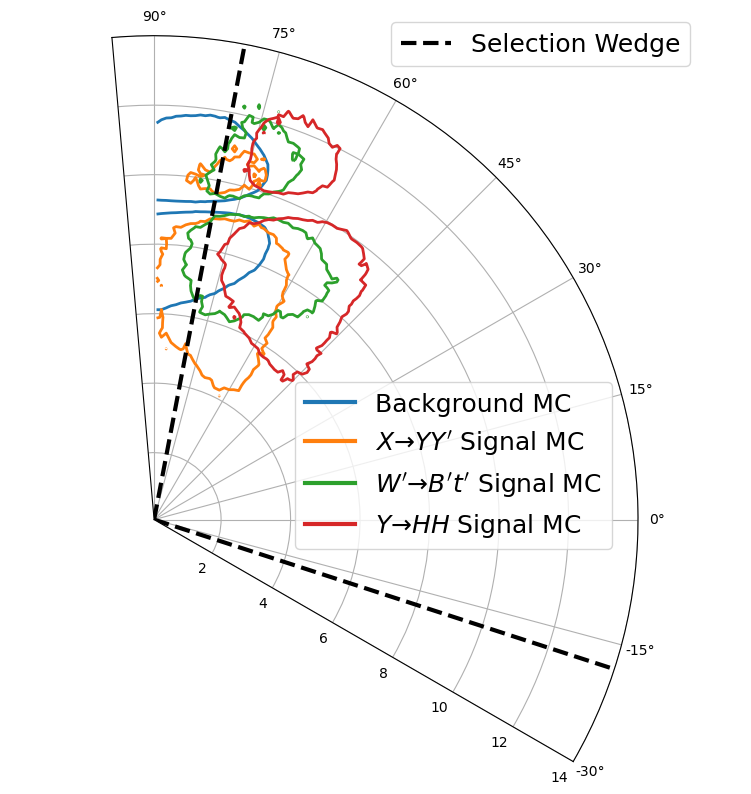

In [74]:
fig, ax = plt.subplots(figsize=(8,8),subplot_kw={'projection': 'polar'})
#levels = [0.01,0.02,0.05,0.08]
#linestyles = ['-','--','-.',':']
levels = [0.01]
linestyles = ['-']
plt.contour(np.arctan2(yy,xx),np.sqrt(xx**2+yy**2),h.T,levels,linewidths=2,colors='C0',linestyles=linestyles,alpha=1)
plt.contour(np.arctan2(yy,xx),np.sqrt(xx**2+yy**2),h_s.T,levels,linewidths=2,colors='C1',linestyles=linestyles,alpha=1)
plt.contour(np.arctan2(yy,xx),np.sqrt(xx**2+yy**2),h_wp.T,levels,linewidths=2,colors='C2',linestyles=linestyles,alpha=1)
plt.contour(np.arctan2(yy,xx),np.sqrt(xx**2+yy**2),h_yh.T,levels,linewidths=2,colors='C3',linestyles=linestyles,alpha=1)

plt.axvline(minangle,color='black',linestyle='--',lw=3)
plt.axvline(maxAngle,color='black',linestyle='--',lw=3)
plt.gca().set_thetamin(-30)
plt.gca().set_thetamax(95)
plt.gca().set_rmax(14)

from matplotlib.lines import Line2D
handles = [Line2D([],[],label="Background MC",color="C0",lw=3),
           Line2D([],[],label=r"$X \to YY'$ Signal MC",color="C1",lw=3),
           Line2D([],[],label=r"$W' \to B't'$ Signal MC",color="C2",lw=3),
           Line2D([],[],label=r"$Y \to HH$ Signal MC",color="C3",lw=3)]
leg1 = plt.legend(handles=handles,loc=(0.39,0.29),fontsize=18)
plt.gca().add_artist(leg1)
handles = [Line2D([],[],label="Selection Wedge",lw=3,linestyle='--',color='k')]
plt.legend(handles=handles,loc=(0.52,0.95),fontsize=18)
plt.tight_layout()
#plt.savefig('plots/misc/example_polar_quakSpace_signedL5massBins_withWedge.pdf')

/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:12: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  if sys.path[0] == "":


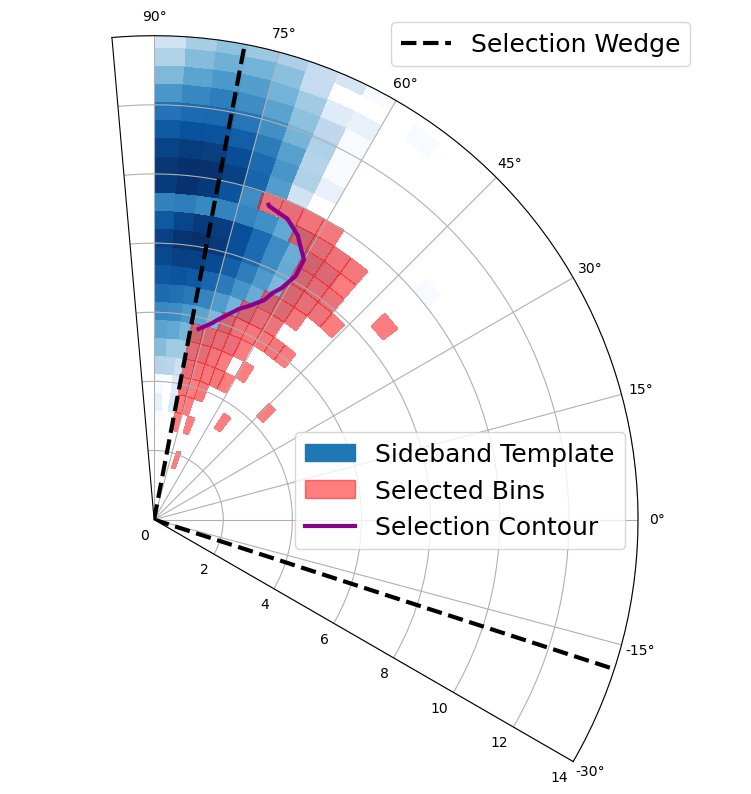

In [51]:
fig, ax = plt.subplots(figsize=(8,8),subplot_kw={'projection': 'polar'})
from matplotlib.colors import Normalize, LogNorm, ListedColormap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
N = 5
dr = rbins[1]-rbins[0]
rbins_ext = np.arange(0,14+dr,dr)
abins_ext = np.linspace(minangle,(0.4 + 0.02*N)*np.pi, angularbincount+N)
hist, _, _ = np.histogram2d(theta[sb], r[sb], bins=(abins_ext, rbins_ext))
hist[hist==0] = np.nan
A,R = np.meshgrid(abins_ext,rbins_ext)
pc = ax.pcolormesh(A, R, hist.T,cmap='Blues',norm=LogNorm())
hist2,_,_ = np.histogram2d(theta[sb],r[sb],bins=(abins,rbins))
A,R = np.meshgrid(abins,rbins)
thresh = 60
cut = (hist2<thresh) & (hist2>0)
hist2[cut] = 100
hist2[~cut] = np.nan
cmap = ListedColormap(['r'])
pc2 = ax.pcolormesh(A, R, hist2.T,cmap=cmap,norm=Normalize(),alpha=0.5)
A,R = np.meshgrid((abins[:-1]+abins[1:])/2,(rbins[:-1]+rbins[1:])/2)
hist2,_,_ = np.histogram2d(theta[sb],r[sb],bins=(abins,rbins))
plt.contour(A,R,hist2.T,[thresh],colors='darkmagenta',linewidths=3)
plt.grid(zorder=0)

plt.axvline(minangle,color='black',linestyle='--',lw=3)
plt.axvline(maxAngle,color='black',linestyle='--',lw=3)
plt.gca().set_thetamin(-30)
plt.gca().set_thetamax(95)
plt.gca().set_rmax(14)

handles = [Patch(label="Sideband Template",color="C0"),Patch(label="Selected Bins",color='r',alpha=0.5),Line2D([],[],label="Selection Contour",lw=3,color='darkmagenta')]
leg1 = plt.legend(handles=handles,loc=(0.39,0.29),fontsize=18)
plt.gca().add_artist(leg1)
handles = [Line2D([],[],label="Selection Wedge",lw=3,linestyle='--',color='k')]
plt.legend(handles=handles,loc=(0.52,0.95),fontsize=18)
plt.tight_layout()
#plt.savefig('plots/misc/example_polar_quakSpaceSelection_signedL5massBins_withWedge.pdf')

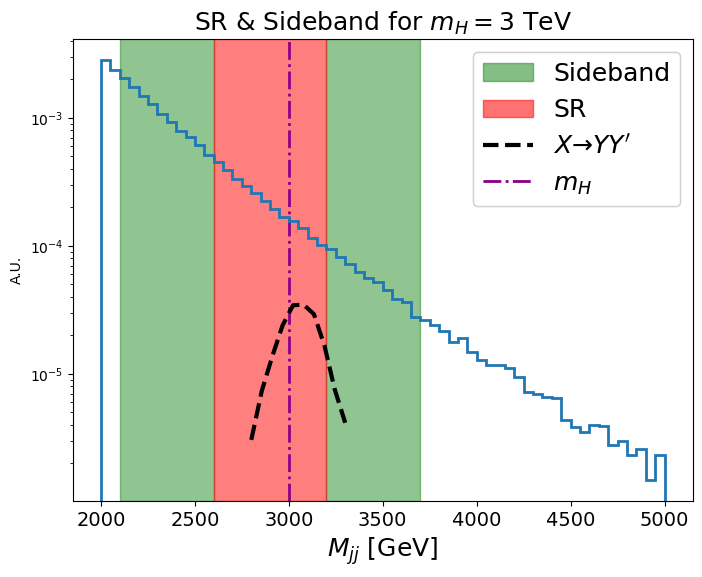

In [53]:
from sklearn.neighbors import KernelDensity
plt.figure(figsize=(8,6))
dm = 50
mbins = np.arange(2000,5000+dm,dm)
h=plt.hist(mass,bins=mbins,histtype='step',zorder=2,lw=2,density=True)
kde_xyymass = KernelDensity(kernel='gaussian').fit(mass_s.reshape(-1,1))
xyymass_m = np.linspace(2800,3300,10)
xyymass_density = 0.01*np.exp(kde_xyymass.score_samples(xyymass_m.reshape(-1,1)))
plt.plot(xyymass_m,xyymass_density,color='k',lw=3,linestyle='--',zorder=2)
sb1 = plt.axvspan(2100,2600,color='forestgreen',alpha=0.5,zorder=1)
sb2 = plt.axvspan(3200,3700,color='forestgreen',alpha=0.5,zorder=1)
sr = plt.axvspan(2600,3200,color='r',alpha=0.5)
plt.axvline(3000,color='darkmagenta',lw=2,linestyle='-.',zorder=1)
plt.yscale('log')
handles = [Patch(label="Sideband",color="forestgreen",alpha=0.5),
           Patch(label="SR",color='r',alpha=0.5),
           Line2D([],[],label=r"$X \to YY'$",lw=3,color='k',linestyle='--'),
           Line2D([],[],label=r"$m_{H}$",lw=2,color='darkmagenta',linestyle='-.')]
leg1 = plt.legend(handles=handles,loc='upper right',fontsize=18)
plt.gca().add_artist(leg1)
plt.xticks(fontsize=14)
#plt.yticks([])
plt.xlabel(r"$M_{jj}$ [GeV]",fontsize=18)
plt.ylabel("A.U.")
plt.title(r"SR & Sideband for $m_H = 3$ TeV",fontsize=18)
plt.savefig("plots/misc/example_sr_sideband_3TeV.pdf")

In [54]:
from quakSpaceMaker_v2 import reductions
ls_b_reduc_sp = reductions["SumProb"].transform(ls_b)
ls_s_reduc_sp = reductions["SumProb"].transform(ls_s)
ls_wp_reduc_sp = reductions["SumProb"].transform(ls_wp)
ls_yh_reduc_sp = reductions["SumProb"].transform(ls_yh)

In [62]:
binsx = np.linspace(-4.2,5,50)
binsy = np.linspace(-5,1,50)
xx,yy = np.meshgrid((binsx[:-1]+binsx[1:])/2,(binsy[:-1]+binsy[1:])/2)
h,b1,b2 = np.histogram2d(lb_b,ls_b_reduc_sp,bins=(binsx,binsy),density=True)
h_s,b1,b2 = np.histogram2d(lb_s,ls_s_reduc_sp,bins=(binsx,binsy),density=True)
h_wp,b1,b2 = np.histogram2d(lb_wp,ls_wp_reduc_sp,bins=(binsx,binsy),density=True)
h_yh,b1,b2 = np.histogram2d(lb_yh,ls_yh_reduc_sp,bins=(binsx,binsy),density=True)

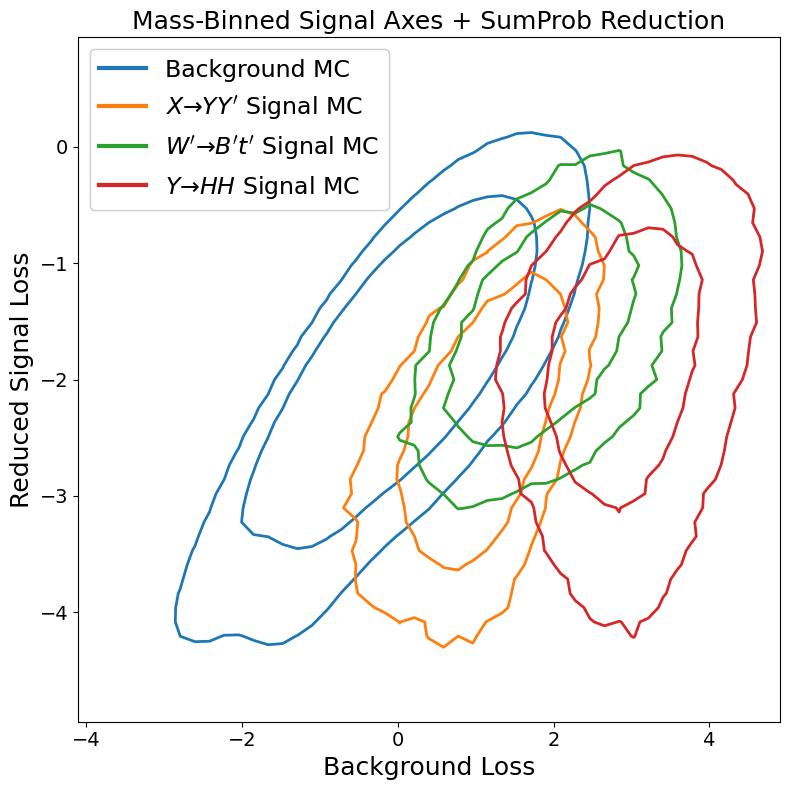

In [64]:
fig, ax = plt.subplots(figsize=(8,8))
#levels = [0.01,0.02,0.05,0.08]
#linestyles = ['-','--','-.',':']
levels = [0.01,0.05]
levels_s = [0.03,0.1]
linestyles = ['-']
plt.contour(xx,yy,h.T,levels,linewidths=2,colors='C0',linestyles=linestyles,alpha=1)
plt.contour(xx,yy,h_s.T,levels_s,linewidths=2,colors='C1',linestyles=linestyles,alpha=1)
plt.contour(xx,yy,h_wp.T,levels_s,linewidths=2,colors='C2',linestyles=linestyles,alpha=1)
plt.contour(xx,yy,h_yh.T,levels_s,linewidths=2,colors='C3',linestyles=linestyles,alpha=1)

from matplotlib.lines import Line2D
handles = [Line2D([],[],label="Background MC",color="C0",lw=3),
           Line2D([],[],label=r"$X \to YY'$ Signal MC",color="C1",lw=3),
           Line2D([],[],label=r"$W' \to B't'$ Signal MC",color="C2",lw=3),
           Line2D([],[],label=r"$Y \to HH$ Signal MC",color="C3",lw=3)]
leg1 = plt.legend(handles=handles,loc='upper left',fontsize=17)
plt.gca().add_artist(leg1)
plt.title(r"Mass-Binned Signal Axes + SumProb Reduction",fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Background Loss",fontsize=18)
plt.ylabel("Reduced Signal Loss",fontsize=18)
plt.tight_layout()
plt.savefig('plots/misc/example_quakSpace_SumProbMassBins.pdf')

In [65]:
from quakSpaceMaker_v2 import reductions
ls_b_reduc_l5 = reductions["signedL5"].transform(ls_b)
ls_s_reduc_l5 = reductions["signedL5"].transform(ls_s)
ls_wp_reduc_l5 = reductions["signedL5"].transform(ls_wp)
ls_yh_reduc_l5 = reductions["signedL5"].transform(ls_yh)

In [66]:
binsx = np.linspace(-3,5,50)
binsy = np.linspace(-5,6,50)
xx,yy = np.meshgrid((binsx[:-1]+binsx[1:])/2,(binsy[:-1]+binsy[1:])/2)
h,b1,b2 = np.histogram2d(lb_b,ls_b_reduc_l5,bins=(binsx,binsy),density=True)
h_s,b1,b2 = np.histogram2d(lb_s,ls_s_reduc_l5,bins=(binsx,binsy),density=True)
h_wp,b1,b2 = np.histogram2d(lb_wp,ls_wp_reduc_l5,bins=(binsx,binsy),density=True)
h_yh,b1,b2 = np.histogram2d(lb_yh,ls_yh_reduc_l5,bins=(binsx,binsy),density=True)

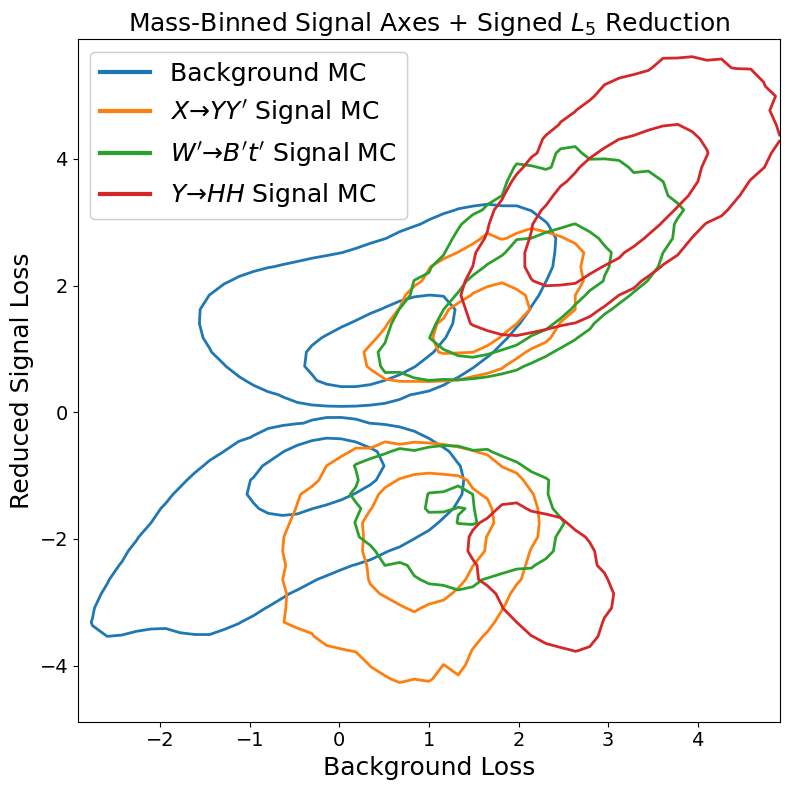

In [68]:
fig, ax = plt.subplots(figsize=(8,8))
#levels = [0.01,0.02,0.05,0.08]
#linestyles = ['-','--','-.',':']
levels = [0.01,0.1]
levels_s = [0.02,0.1]
linestyles = ['-']
plt.contour(xx,yy,h.T,levels,linewidths=2,colors='C0',linestyles=linestyles,alpha=1)
plt.contour(xx,yy,h_s.T,levels_s,linewidths=2,colors='C1',linestyles=linestyles,alpha=1)
plt.contour(xx,yy,h_wp.T,levels_s,linewidths=2,colors='C2',linestyles=linestyles,alpha=1)
plt.contour(xx,yy,h_yh.T,levels_s,linewidths=2,colors='C3',linestyles=linestyles,alpha=1)

from matplotlib.lines import Line2D
handles = [Line2D([],[],label="Background MC",color="C0",lw=3),
           Line2D([],[],label=r"$X \to YY'$ Signal MC",color="C1",lw=3),
           Line2D([],[],label=r"$W' \to B't'$ Signal MC",color="C2",lw=3),
           Line2D([],[],label=r"$Y \to HH$ Signal MC",color="C3",lw=3)]
leg1 = plt.legend(handles=handles,loc='upper left',fontsize=18)
plt.gca().add_artist(leg1)
plt.title(r"Mass-Binned Signal Axes + Signed $L_5$ Reduction",fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Background Loss",fontsize=18)
plt.ylabel("Reduced Signal Loss",fontsize=18)
plt.tight_layout()
plt.savefig('plots/misc/example_quakSpace_signedL5massBins.pdf')

# Single Axis

In [75]:
bkg_axis = "BKG_mjjFlat"
sig_axes = ["XYY3000_Y170_Yp170","YHH3000_H400","Wp3000_B400_T170"]

with h5py.File("lossEvals_pcaDecorr_boxCox/BKG.h5","r") as f:
    mjj = f["mjj"][()]
    lb_b = f[bkg_axis][()]
    ls_b = np.concatenate([f[s][()].reshape(-1,1) for s in sig_axes],axis=1)
    
with h5py.File("lossEvals_pcaDecorr_boxCox/XYY3000_Y170_Yp170.h5","r") as f:
    mjj_s = f['mjj'][()]
    lb_s = f[bkg_axis][()]
    ls_s = np.concatenate([f[s][()].reshape(-1,1) for s in sig_axes],axis=1)
    
with h5py.File("lossEvals_pcaDecorr_boxCox/YHH3000_H400.h5","r") as f:
    mjj_yh = f['mjj'][()]
    lb_yh = f[bkg_axis][()]
    ls_yh = np.concatenate([f[s][()].reshape(-1,1) for s in sig_axes],axis=1)
    
with h5py.File("lossEvals_pcaDecorr_boxCox/Wp3000_B400_T170.h5","r") as f:
    mjj_wp = f['mjj'][()]
    lb_wp = f[bkg_axis][()]
    ls_wp = np.concatenate([f[s][()].reshape(-1,1) for s in sig_axes],axis=1)

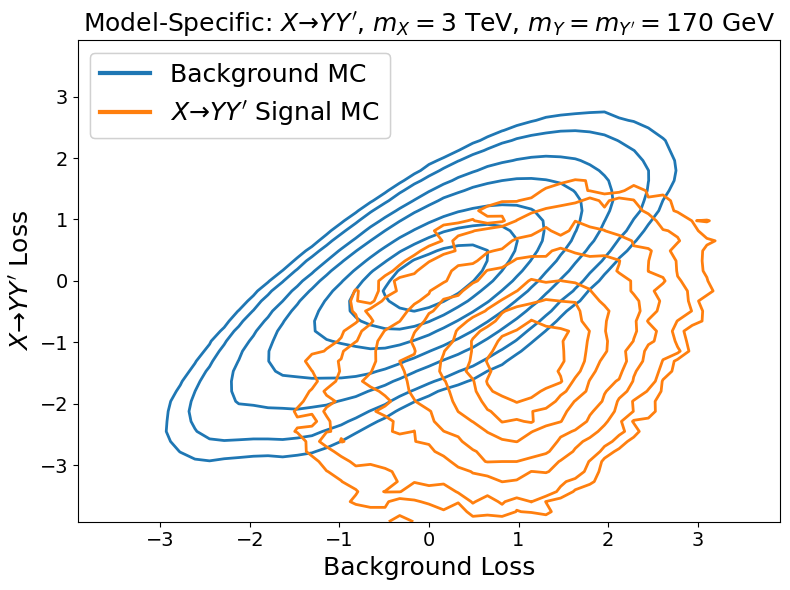

In [101]:
plt.figure(figsize=(8,6))
binsx = np.linspace(-4,4,50)
binsy = np.linspace(-4,4,50)
xx,yy = np.meshgrid((binsx[:-1]+binsx[1:])/2,(binsy[:-1]+binsy[1:])/2)
hb,b1,b2 = np.histogram2d(lb_b,ls_b[:,0],bins=(binsx,binsy),density=True)
hs,b1,b2 = np.histogram2d(lb_s,ls_s[:,0],bins=(binsx,binsy),density=True)

levels = [0.005,0.01,0.025,0.05,0.1,0.15,0.2]
plt.contour(xx,yy,hb.T,levels,linewidths=2,colors='C0',linestyles=linestyles,alpha=1)
plt.contour(xx,yy,hs.T,levels,linewidths=2,colors='C1',linestyles=linestyles,alpha=1)
handles = [Line2D([],[],label="Background MC",color="C0",lw=3),
           Line2D([],[],label=r"$X \to YY'$ Signal MC",color="C1",lw=3)]
           #Line2D([],[],label=r"$W' \to B't'$ Signal MC",color="C2",lw=3),
           #Line2D([],[],label=r"$Y \to HH$ Signal MC",color="C3",lw=3)]
leg1 = plt.legend(handles=handles,loc='upper left',fontsize=18)
plt.gca().add_artist(leg1)
plt.title(r"Model-Specific: $X \to YY'$, $m_X = 3$ TeV, $m_Y = m_{Y'} = 170$ GeV",fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Background Loss",fontsize=18)
plt.ylabel(r"$X \to YY'$ Loss",fontsize=18)
plt.tight_layout()
plt.savefig('plots/misc/example_modSpecific_space_XYY.pdf')

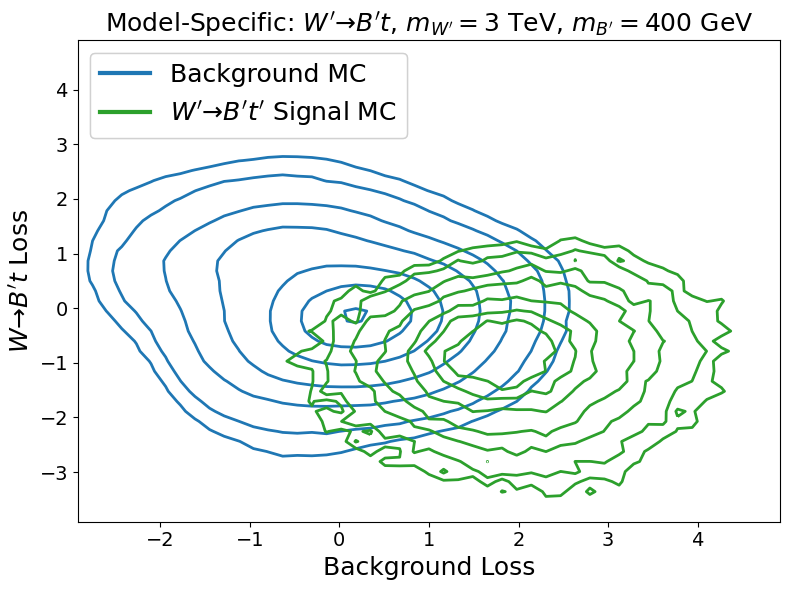

In [102]:
plt.figure(figsize=(8,6))
binsx = np.linspace(-3,5,50)
binsy = np.linspace(-4,5,50)
xx,yy = np.meshgrid((binsx[:-1]+binsx[1:])/2,(binsy[:-1]+binsy[1:])/2)
hb,b1,b2 = np.histogram2d(lb_b,ls_b[:,1],bins=(binsx,binsy),density=True)
hs,b1,b2 = np.histogram2d(lb_wp,ls_wp[:,1],bins=(binsx,binsy),density=True)

levels = [0.005,0.01,0.025,0.05,0.1,0.15,0.2]
plt.contour(xx,yy,hb.T,levels,linewidths=2,colors='C0',linestyles=linestyles,alpha=1)
plt.contour(xx,yy,hs.T,levels,linewidths=2,colors='C2',linestyles=linestyles,alpha=1)
handles = [Line2D([],[],label="Background MC",color="C0",lw=3),
           #Line2D([],[],label=r"$X \to YY'$ Signal MC",color="C1",lw=3)]
           Line2D([],[],label=r"$W' \to B't'$ Signal MC",color="C2",lw=3)]
           #Line2D([],[],label=r"$Y \to HH$ Signal MC",color="C3",lw=3)]
leg1 = plt.legend(handles=handles,loc='upper left',fontsize=18)
plt.gca().add_artist(leg1)
plt.title(r"Model-Specific: $W' \to B't$, $m_{W'} = 3$ TeV, $m_{B'} = 400$ GeV",fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Background Loss",fontsize=18)
plt.ylabel(r"$W \to B't$ Loss",fontsize=18)
plt.tight_layout()
plt.savefig('plots/misc/example_modSpecific_space_Wprime.pdf')

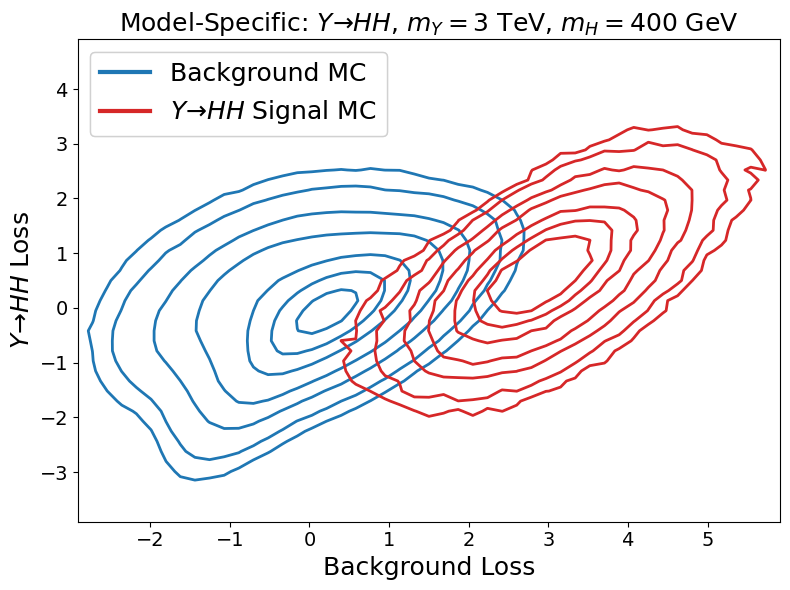

In [103]:
plt.figure(figsize=(8,6))
binsx = np.linspace(-3,6,50)
binsy = np.linspace(-4,5,50)
xx,yy = np.meshgrid((binsx[:-1]+binsx[1:])/2,(binsy[:-1]+binsy[1:])/2)
hb,b1,b2 = np.histogram2d(lb_b,ls_b[:,2],bins=(binsx,binsy),density=True)
hs,b1,b2 = np.histogram2d(lb_yh,ls_yh[:,2],bins=(binsx,binsy),density=True)

levels = [0.005,0.01,0.025,0.05,0.1,0.15,0.2]
plt.contour(xx,yy,hb.T,levels,linewidths=2,colors='C0',linestyles=linestyles,alpha=1)
plt.contour(xx,yy,hs.T,levels,linewidths=2,colors='C3',linestyles=linestyles,alpha=1)
handles = [Line2D([],[],label="Background MC",color="C0",lw=3),
           #Line2D([],[],label=r"$X \to YY'$ Signal MC",color="C1",lw=3)]
           #Line2D([],[],label=r"$W' \to B't'$ Signal MC",color="C2",lw=3)]
           Line2D([],[],label=r"$Y \to HH$ Signal MC",color="C3",lw=3)]
leg1 = plt.legend(handles=handles,loc='upper left',fontsize=18)
plt.gca().add_artist(leg1)
plt.title(r"Model-Specific: $Y \to HH$, $m_{Y} = 3$ TeV, $m_{H} = 400$ GeV",fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Background Loss",fontsize=18)
plt.ylabel(r"$Y \to HH$ Loss",fontsize=18)
plt.tight_layout()
plt.savefig('plots/misc/example_modSpecific_space_YHH.pdf')